# Avaliacao da Qualidade de Dados Sinteticos

> **Nota:** Para garantir compatibilidade de exibicao em todas as plataformas (NBViewer, GitHub, etc.), os caracteres acentuados do portugues (a, e, c, etc.) foram substituidos por suas versoes sem acento neste notebook. O conteudo e a analise permanecem inalterados.

### Analise Comportamental de Usuarios em Interfaces Digitais

**Objetivo:** ao final deste caderno, voce devera ser capaz de avaliar se uma base sintetica e boa o suficiente para o proposito que a originou — e comunicar essa avaliacao de forma defensavel.

**Mapa do que vamos fazer:**

| Etapa | O que fazemos | Por que isso importa |
|-------|---------------|----------------------|
| 0 | Configuracao do ambiente | Carregar a base do E02 com reprodutibilidade |
| 1 | O que significa "qualidade" aqui | Qualidade e relativa ao proposito |
| 2 | Coerencia interna | Relacoes entre variaveis fazem sentido? |
| 3 | Cobertura e diversidade | A base representa todos os grupos esperados? |
| 4 | Fidelidade estatistica | As distribuicoes batem com os sinais reais? |
| 5 | Deteccao de vazamentos sinteticos | A base "parece" artificial demais? |
| 6 | Auditoria de hipoteses | As hipoteses do E02 foram honradas nao dado? |
| 7 | Scorecard de qualidade | Consolidar tudo em uma avaliacao unica |
| 8 | Exercicios praticos | Consolidar o raciocinio |

## Passo 0 | Configure seu ambiente

Base gerada no E02, arquivo `dados/base_sintetica_e02.csv`. Aqui ela e o objeto de avaliacao, nao uma verdade assumida.

In [1]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
import math
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

np.random.seed(42)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

avaliacoes = []  # preenchida ao longo do caderno; consolidada no Passo 7

print('Ambiente configurado com sucesso.')
print(f'   numpy   {np.__version__}')
print(f'   pandas  {pd.__version__}')

Ambiente configurado com sucesso.
   numpy   2.4.4
   pandas  3.0.2


In [2]:
# Parametros e funcoes auxiliares do E02 usados nas comparacoes e exercicios.
# A base principal sera baixada/carregada como CSV; este bloco apenas preserva as referencias metodologicas.

SEED = 42
N_SESSOES = 5000
perfis = ["Pesquisador", "Administrativo", "Tecnico", "Operacional"]
pesos_perfil = [0.30, 0.27, 0.25, 0.18]

tipos_dispositivo = ["desktop", "mobile_web", "mobile_app"]
pesos_dispositivo = [0.974, 0.014, 0.012]

dias_semana = ["segunda", "terca", "quarta", "quinta", "sexta", "sabado", "domingo"]
pesos_dia = [0.19, 0.18, 0.20, 0.17, 0.16, 0.05, 0.05]

faixas_horarias = ["06-08", "08-11", "11-14", "14-17", "17-20", "20-06"]
pesos_faixa = [0.12, 0.41, 0.17, 0.18, 0.08, 0.04]

objetivos_por_perfil = {
    "Pesquisador": {
        "buscar_documento": 0.34,
        "ler_comunicado": 0.22,
        "buscar_sistema": 0.18,
        "buscar_pessoa": 0.08,
        "acompanhar_noticias": 0.18,
    },
    "Administrativo": {
        "buscar_sistema": 0.36,
        "buscar_documento": 0.20,
        "ler_comunicado": 0.20,
        "buscar_pessoa": 0.10,
        "acompanhar_noticias": 0.14,
    },
    "Tecnico": {
        "buscar_documento": 0.28,
        "buscar_sistema": 0.30,
        "ler_comunicado": 0.14,
        "buscar_pessoa": 0.10,
        "acompanhar_noticias": 0.18,
    },
    "Operacional": {
        "buscar_sistema": 0.26,
        "ler_comunicado": 0.26,
        "acompanhar_noticias": 0.22,
        "buscar_documento": 0.14,
        "buscar_pessoa": 0.12,
    },
}

tipo_conteudo_por_objetivo = {
    "buscar_sistema": "Site Page",
    "buscar_documento": "Document",
    "buscar_pessoa": "Site Page",
    "ler_comunicado": "News Post",
    "acompanhar_noticias": "News Post",
}

lambdas_pageviews = {
    "buscar_sistema": 3.2,
    "buscar_documento": 2.6,
    "buscar_pessoa": 2.0,
    "ler_comunicado": 3.7,
    "acompanhar_noticias": 4.2,
}

origens = ["home_direta", "busca_interna", "link_email", "atalho_sistema"]


def escolher_com_pesos(opcoes, pesos):
    pesos = np.array(pesos, dtype=float)
    soma_pesos = pesos.sum()
    if soma_pesos <= 0:
        raise ValueError("A soma dos pesos deve ser positiva.")
    return np.random.choice(opcoes, p=pesos / soma_pesos)


def escolher_objetivo(perfil):
    dist = objetivos_por_perfil[perfil]
    return escolher_com_pesos(list(dist.keys()), list(dist.values()))


def escolher_origem(objetivo, faixa_horaria):
    mapa_pesos = {
        "buscar_sistema": [0.25, 0.20, 0.05, 0.50],
        "buscar_documento": [0.24, 0.44, 0.10, 0.22],
        "ler_comunicado": [0.38, 0.10, 0.32, 0.20],
        "acompanhar_noticias": [0.46, 0.08, 0.28, 0.18],
    }
    pesos = mapa_pesos.get(objetivo, [0.28, 0.32, 0.10, 0.30])
    origem = escolher_com_pesos(origens, pesos)
    if faixa_horaria == "08-11" and objetivo == "buscar_sistema" and np.random.rand() < 0.25:
        origem = "atalho_sistema"
    return origem


def gerar_pageviews(objetivo, tipo_dispositivo):
    lam = lambdas_pageviews[objetivo]
    if tipo_dispositivo != "desktop":
        lam = max(1.5, lam - 0.6)
    return max(1, np.random.poisson(lam))


def gerar_tempos(objetivo, usou_busca, faixa_horaria):
    params = {
        "buscar_sistema": (4.0, 0.55, 3.2, 0.60),
        "buscar_documento": (4.0, 0.55, 3.2, 0.60),
        "buscar_pessoa": (4.0, 0.55, 3.2, 0.60),
        "ler_comunicado": (2.9, 0.45, 4.3, 0.55),
        "acompanhar_noticias": (3.2, 0.50, 4.0, 0.60),
    }
    mu_b, sig_b, mu_l, sig_l = params.get(objetivo, (3.5, 0.50, 3.8, 0.55))
    tempo_busca = np.random.lognormal(mu_b, sig_b)
    tempo_leitura = np.random.lognormal(mu_l, sig_l)
    if not usou_busca:
        tempo_busca *= 0.45
    if faixa_horaria == "08-11":
        tempo_leitura *= 0.88
        tempo_busca *= 1.08
    ruido = np.random.gamma(shape=2.0, scale=8.0)
    tempo_total = tempo_busca + tempo_leitura + ruido
    return tempo_busca, tempo_leitura, tempo_total


def gerar_flags(objetivo, origem_acesso):
    usou_busca = int(
        origem_acesso == "busca_interna"
        or (objetivo in {"buscar_documento", "buscar_pessoa"} and np.random.rand() < 0.45)
    )
    clicou_comunicado = int(objetivo in {"ler_comunicado", "acompanhar_noticias"} and np.random.rand() < 0.78)
    clicou_link_operacional = int(objetivo in {"buscar_sistema", "buscar_documento"} and np.random.rand() < 0.72)
    return usou_busca, clicou_comunicado, clicou_link_operacional


def gerar_sucesso(objetivo, usou_busca, tipo_dispositivo):
    probs_base = {
        "buscar_sistema": 0.76,
        "buscar_documento": 0.68,
        "buscar_pessoa": 0.72,
        "ler_comunicado": 0.81,
        "acompanhar_noticias": 0.79,
    }
    p = probs_base[objetivo]
    if usou_busca:
        p -= 0.07
    if tipo_dispositivo != "desktop":
        p -= 0.04
    p = min(max(p, 0.15), 0.95)
    return int(np.random.rand() < p)


def gerar_base(n_sessoes=N_SESSOES, pesos_perfil_override=None, gerar_tempos_fn=None):
    pesos_p = pesos_perfil_override if pesos_perfil_override is not None else pesos_perfil
    tempos_fn = gerar_tempos_fn if gerar_tempos_fn is not None else gerar_tempos
    linhas = []
    for i in range(1, n_sessoes + 1):
        perfil = escolher_com_pesos(perfis, pesos_p)
        dispositivo = escolher_com_pesos(tipos_dispositivo, pesos_dispositivo)
        dia = escolher_com_pesos(dias_semana, pesos_dia)
        faixa = escolher_com_pesos(faixas_horarias, pesos_faixa)
        objetivo = escolher_objetivo(perfil)
        origem = escolher_origem(objetivo, faixa)
        usou_busca, clicou_comunicado, clicou_link_operacional = gerar_flags(objetivo, origem)
        pageviews = gerar_pageviews(objetivo, dispositivo)
        try:
            tempo_busca, tempo_leitura, tempo_total = tempos_fn(objetivo, usou_busca, faixa, dia)
        except TypeError:
            tempo_busca, tempo_leitura, tempo_total = tempos_fn(objetivo, usou_busca, faixa)
        sucesso = gerar_sucesso(objetivo, usou_busca, dispositivo)
        n_interacoes = int(pageviews + clicou_comunicado + clicou_link_operacional + usou_busca)
        prop_leitura = round(tempo_leitura / tempo_total, 4) if tempo_total > 0 else 0
        abandono = int((tempo_total < 35 and pageviews <= 2) or (sucesso == 0 and tempo_total < 45))
        linhas.append(
            {
                "session_id": i,
                "perfil_usuario": perfil,
                "tipo_dispositivo": dispositivo,
                "dia_semana": dia,
                "faixa_horaria": faixa,
                "origem_acesso": origem,
                "objetivo_sessao": objetivo,
                "pageviews": pageviews,
                "tempo_busca_segundos": round(tempo_busca, 2),
                "tempo_leitura_segundos": round(tempo_leitura, 2),
                "tempo_total_segundos": round(tempo_total, 2),
                "usou_busca": usou_busca,
                "clicou_comunicado": clicou_comunicado,
                "clicou_link_operacional": clicou_link_operacional,
                "sucesso_encontrou_o_que_queria": sucesso,
                "tipo_conteudo_principal": tipo_conteudo_por_objetivo[objetivo],
                "numero_interacoes": n_interacoes,
                "proporcao_tempo_leitura": prop_leitura,
                "abandono_rapido": abandono,
            }
        )
    return pd.DataFrame(linhas)


def inserir_outliers_realistas(df):
    df = df.copy()
    idx_tempo = df.sample(frac=0.006, random_state=42).index
    fator_tempo = np.random.uniform(2.2, 4.0, len(idx_tempo))
    df.loc[idx_tempo, "tempo_leitura_segundos"] *= fator_tempo
    df.loc[idx_tempo, "tempo_total_segundos"] = (
        df.loc[idx_tempo, "tempo_busca_segundos"]
        + df.loc[idx_tempo, "tempo_leitura_segundos"]
        + np.random.uniform(10, 35, len(idx_tempo))
    )

    idx_pv = df.sample(frac=0.004, random_state=7).index
    df.loc[idx_pv, "pageviews"] += np.random.randint(8, 18, len(idx_pv))
    df.loc[idx_pv, "numero_interacoes"] = (
        df.loc[idx_pv, "pageviews"]
        + df.loc[idx_pv, "clicou_comunicado"]
        + df.loc[idx_pv, "clicou_link_operacional"]
        + df.loc[idx_pv, "usou_busca"]
    )

    df["proporcao_tempo_leitura"] = (df["tempo_leitura_segundos"] / df["tempo_total_segundos"]).round(4)
    df["abandono_rapido"] = (
        ((df["tempo_total_segundos"] < 35) & (df["pageviews"] <= 2))
        | ((df["sucesso_encontrou_o_que_queria"] == 0) & (df["tempo_total_segundos"] < 45))
    ).astype(int)
    return df


print('Funcoes e parametros base carregados com sucesso.')

Funcoes e parametros base carregados com sucesso.


### Carregando a base sintetica do E02

A base foi gerada no E02 e disponibilizada no Google Drive. No Colab, o arquivo e baixado automaticamente com `gdown`; localmente, o cadernao reutiliza uma copia ja existente se ela estiver em `dados/`.

In [3]:
URL_DATASET_E02 = 'https://drive.google.com/file/d/1Aba1Be9RTfTAO7qUFQ4vJAEDkTvamfmS/view?usp=sharing'
CAMINHO_DATASET = Path('dados/dataset.csv')
CAMINHO_LOCAL_LEGADO = Path('dados/base_sintetica_e02.csv')

CAMINHO_DATASET.parent.mkdir(parents=True, exist_ok=True)

if CAMINHO_DATASET.exists():
    caminho_base = CAMINHO_DATASET
    origem_base = 'arquivo local ja baixado'
elif CAMINHO_LOCAL_LEGADO.exists():
    caminho_base = CAMINHO_LOCAL_LEGADO
    origem_base = 'arquivo local do repositorio'
else:
    try:
        import gdown
    except ImportError as exc:
        raise ImportError(
            'O pacote gdown e necessario para baixar o dataset nao Colab. '
            'Execute: !pip install gdown'
        ) from exc

    print('Baixando dataset do Google Drive...')
    gdown.download(url=URL_DATASET_E02, output=str(CAMINHO_DATASET), quiet=False, )
    caminho_base = CAMINHO_DATASET
    origem_base = 'Google Drive via gdown'

df = pd.read_csv(caminho_base)

print(f'Base carregada de {origem_base}: {len(df):,} sessoes, {df.shape[1]} variaveis.')
print(f'Arquivo usado: {caminho_base}')
df.head(3)

Base carregada de arquivo local ja baixado: 5,000 sessoes, 19 variaveis.
Arquivo usado: dados\dataset.csv


,session_id,perfil_usuario,tipo_dispositivo,dia_semana,faixa_horaria,origem_acesso,objetivo_sessao,pageviews,tempo_busca_segundos,tempo_leitura_segundos,tempo_total_segundos,usou_busca,clicou_comunicado,clicou_link_operacional,sucesso_encontrou_o_que_queria,tipo_conteudo_principal,numero_interacoes,proporcao_tempo_leitura,abandono_rapido
0,1,Administrativo,desktop,quinta,11-14,home_direta,buscar_sistema,3,17.85,17.90,44.01,0,0,1,1,Site Page,4,0.4067,0
1,2,Pesquisador,desktop,segunda,08-11,busca_interna,ler_comunicado,3,12.95,34.44,64.99,1,0,0,0,News Post,4,0.5299,0
2,3,Operacional,desktop,terca,06-08,home_direta,acompanhar_noticias,3,5.86,105.13,178.53,0,1,0,0,News Post,4,0.5889,0


## Passo 1 | O que significa "qualidade" aqui

Antes de qualquer analise, uma pergunta direta:

> **Voce confiaria nessa base para tomar uma decisao de negocio? Por que?**
>
> Escreva sua resposta aqui, antes de ver qualquer analise. Volte a essa resposta ao final do caderno.

###  Resposta ao Fechamento (Passo 1)
**"Voce confiaria nessa base para tomar uma decisao de negocio? Por que?"**

> **Sim, mas apenas para decisoes taticas e descritivas**. Confio na base para otimizar arquitetura de informacao (ex: reposicionar atalhos, ja que a origem de acesso influencia a UX). No entanto, **nao confiaria** para decisoes estrategicas ou financeiras criticas (como dimensionar infraestrutura de servidores), pois a falta de anomalias e de variancia nao-linear da base falharia em simular gargalos reais. E uma ferramenta direcional, nao preditiva.

Qualidade de dados sinteticos e relativa ao proposito. A pergunta nao e *"esses dados sao realistas?"*, mas *"sao adequados para a decisao que precisamos tomar?"*

Proposito (E02):

> **Sustentar decisoes sobre como aumentar o Engajamento com comunicados internos na intranet do IPT.**

| Eixo | Pergunta central | O que verificamos |
|------|-----------------|-------------------|
| **Coerencia interna** | As relacoes entre variaveis fazem sentido? | Correlacoes e agrupamentos esperados |
| **Cobertura e diversidade** | A base representa todos os grupos esperados? | Frequencias por segmento |
| **Fidelidade estatistica** | As distribuicoes batem com os sinais reais? | Comparacao com ancoras do E02 |
| **Realismo** | A base parece artificial demais? | Checklist de vazamentos sinteticos |

## Passo 2 | Coerencia interna

Se uma base sintetica viola relacoes obvias entre variaveis, qualquer analise construida sobre ela produzira conclusoes questionaveis.

Em cada verificacao: *isso contradiz alguma hipotese do E02?*

### 2.1 | Tempo de leitura × clicou_comunicado

**Hipotese do E02:** usuarios que clicam em comunicados passam mais tempo lendo. Se essa relacao nao aparecer nos dados, a variavel `tempo_leitura_segundos` nao esta cumprindo seu papel.

**Criterio:** a mediana de `tempo_leitura_segundos` deve ser *maior* para quem clicou. Nao exigimos uma magnitude especifica — apenas a direcao correta.

In [4]:
fig = px.box(
    df,
    x='clicou_comunicado',
    y='tempo_leitura_segundos',
    color='clicou_comunicado',
    points=False,
    labels={
        'clicou_comunicado': 'Clicou em comunicado',
        'tempo_leitura_segundos': 'Tempo de leitura (segundos)',
    },
    title='Coerencia 2.1 | Tempo de leitura por grupo de Engajamento com comunicado',
    color_discrete_map={0: '#94a3b8', 1: '#1d4ed8'},
)
fig.update_layout(showlegend=False)

mediana_0 = df[df['clicou_comunicado'] == 0]['tempo_leitura_segundos'].median()
mediana_1 = df[df['clicou_comunicado'] == 1]['tempo_leitura_segundos'].median()
fig

print('Celula executada com sucesso.')

Celula executada com sucesso.


In [5]:
direcao_ok_21 = mediana_1 > mediana_0
status_21 = '[OK]' if direcao_ok_21 else '[FALHA]'
risco_21 = 'Baixo' if direcao_ok_21 else 'Alto'

print('─' * 65)
print(f'Observado:     clicou = {mediana_1:.0f}s | nao clicou = {mediana_0:.0f}s  (diferenca: {mediana_1 - mediana_0:+.0f}s)')
if direcao_ok_21:
    print('Interpretacao: direcao correta — mais Engajamento implica mais tempo de leitura.')
    print('Decisao:       [OK] Baixo risco — tempo_leitura_segundos e confiavel para segmentar Engajamento.')
else:
    print('Interpretacao: [FALHA] direcao INVERTIDA — revisar gerar_tempos() no E02.')
    print('Decisao:       [FALHA] Alto risco — a variavel nao reflete o comportamento modelado.')

avaliacoes.append({
    'eixo': 'Coerencia',
    'criterio': 'Tempo de leitura maior para quem clicou em comunicado',
    'observado': f'clicou: {mediana_1:.0f}s | nao clicou: {mediana_0:.0f}s ({mediana_1 - mediana_0:+.0f}s)',
    'status': status_21,
    'risco': risco_21,
})

─────────────────────────────────────────────────────────────────
Observado:     clicou = 61s | nao clicou = 26s  (diferenca: +36s)
Interpretacao: direcao correta — mais Engajamento implica mais tempo de leitura.
Decisao:       [OK] Baixo risco — tempo_leitura_segundos e confiavel para segmentar Engajamento.


### 2.2 | Abandonao rapido × pageviews

**Hipotese do E02:** sessoes de abandonao rapido tem menos pageviews. Se isso nao ocorrer, a regra derivada de `abandono_rapido` esta inconsistente com a variavel `pageviews`.

**Criterio (direcional):** a mediana de `pageviews` deve ser *menor* nas sessoes com abandonao rapido. A magnitude nao e prescrita — esperamos apenas a direcao correta.

In [6]:
fig = px.box(
    df,
    x='abandono_rapido',
    y='pageviews',
    color='abandono_rapido',
    points=False,
    labels={
        'abandono_rapido': 'Abandonao rapido',
        'pageviews': 'Pageviews',
    },
    title='Coerencia 2.2 | Pageviews por grupo de abandono',
    color_discrete_map={0: '#94a3b8', 1: '#dc2626'},
)
fig.update_layout(showlegend=False)

mediana_nao = df[df['abandono_rapido'] == 0]['pageviews'].median()
mediana_sim = df[df['abandono_rapido'] == 1]['pageviews'].median()
fig

print('Celula executada com sucesso.')

Celula executada com sucesso.


In [7]:
direcao_ok_22 = mediana_sim < mediana_nao
status_22 = '[OK]' if direcao_ok_22 else '[FALHA]'
risco_22 = 'Baixo' if direcao_ok_22 else 'Alto'

print('─' * 65)
print(f'Observado:     sem abandonao = {mediana_nao:.1f} pv | com abandonao = {mediana_sim:.1f} pv')
if direcao_ok_22:
    print('Interpretacao: abandonao rapido esta corretamente associado a menos paginas visitadas.')
    print('Decisao:       [OK] Baixo risco — abandono_rapido e coerente como proxy de desEngajamento.')
else:
    print('Interpretacao: [FALHA] relacao INVERTIDA — revisar a regra de abandonao em gerar_base() no E02.')
    print('Decisao:       [FALHA] Alto risco — abandono_rapido nao pode ser usado como proxy confiavel.')

avaliacoes.append({
    'eixo': 'Coerencia',
    'criterio': 'Abandonao rapido associado a menos pageviews',
    'observado': f'sem: {mediana_nao:.1f} pv | com: {mediana_sim:.1f} pv',
    'status': status_22,
    'risco': risco_22,
})

─────────────────────────────────────────────────────────────────
Observado:     sem abandonao = 3.0 pv | com abandonao = 2.0 pv
Interpretacao: abandonao rapido esta corretamente associado a menos paginas visitadas.
Decisao:       [OK] Baixo risco — abandono_rapido e coerente como proxy de desEngajamento.


### 2.3 | Objetivo da sessao × taxa de clique em comunicado

**Hipotese do E02:** apenas sessoes com objetivo `ler_comunicado` ou `acompanhar_noticias` tem alta taxa de clique. Outros objetivos deveriam ter taxa proxima de zero.

**Criterio (quantitativo):** a taxa de clique em `ler_comunicado` deve ser pelo menos 3× maior do que a taxa dos demais objetivos combinados. Sem essa separacao, `objetivo_sessao` nao serve para segmentar Engajamento.

In [8]:
taxa_por_objetivo = (
    df.groupby('objetivo_sessao')['clicou_comunicado']
    .mean()
    .reset_index()
    .rename(columns={'clicou_comunicado': 'taxa_clique_comunicado'})
    .sort_values('taxa_clique_comunicado', ascending=True)
)

fig = px.bar(
    taxa_por_objetivo,
    x='taxa_clique_comunicado',
    y='objetivo_sessao',
    orientation='h',
    title='Coerencia 2.3 | Taxa de clique em comunicado por objetivo de sessao',
    labels={
        'taxa_clique_comunicado': 'Taxa de clique em comunicado',
        'objetivo_sessao': 'Objetivo',
    },
    text=taxa_por_objetivo['taxa_clique_comunicado'].apply(lambda x: f'{x:.0%}'),
)
fig.update_traces(marker_color='#1d4ed8', textposition='outside')
fig.update_xaxes(tickformat='.0%')
fig

print('Celula executada com sucesso.')

Celula executada com sucesso.


In [9]:
taxa_ler_23 = taxa_por_objetivo.loc[taxa_por_objetivo['objetivo_sessao'] == 'ler_comunicado', 'taxa_clique_comunicado'].values[0]
taxa_outros_23 = taxa_por_objetivo.loc[taxa_por_objetivo['objetivo_sessao'] != 'ler_comunicado', 'taxa_clique_comunicado'].mean()
razao_23 = taxa_ler_23 / taxa_outros_23 if taxa_outros_23 > 0 else float('inf')
segmentacao_ok = razao_23 >= 3
status_23 = '[OK]' if segmentacao_ok else '[AVISO]'
risco_23 = 'Baixo' if segmentacao_ok else 'Medio'

print('─' * 65)
print(f'Observado:     ler_comunicado → {taxa_ler_23:.0%} | media outros objetivos → {taxa_outros_23:.0%}  (razao: {razao_23:.1f}×)')
print(f'Criterio:      razao ≥ 3×')
if segmentacao_ok:
    print('Interpretacao: segmentacao correta — objetivo de sessao determina o comportamento de clique.')
    print('Decisao:       [OK] Baixo risco — analise por objetivo_sessao e confiavel para Engajamento.')
else:
    print('Interpretacao: [AVISO] diferenca menor que o esperado — verificar gerar_flags() no E02.')
    print('Decisao:       [AVISO] Medio risco — analise segmentada pode misturar grupos com comportamentos similares.')

avaliacoes.append({
    'eixo': 'Coerencia',
    'criterio': 'Taxa de clique em comunicado ≥ 3× maior em ler_comunicado vs. demais',
    'observado': f'ler_comunicado: {taxa_ler_23:.0%} | outros: {taxa_outros_23:.0%} ({razao_23:.1f}×)',
    'status': status_23,
    'risco': risco_23,
})

─────────────────────────────────────────────────────────────────
Observado:     ler_comunicado → 77% | media outros objetivos → 19%  (razao: 4.0×)
Criterio:      razao ≥ 3×
Interpretacao: segmentacao correta — objetivo de sessao determina o comportamento de clique.
Decisao:       [OK] Baixo risco — analise por objetivo_sessao e confiavel para Engajamento.


### Mini-exercicio 2.1 — Identificando uma incoerencia

Observe a matriz de correlacao abaixo entre as variaveis numericas da base.

Identifique **um par de variaveis** onde a correlacao observada e diferente do que voce esperaria pelo modelo do E02. Justifique: isso e um problema real ou um comportamento esperado?

<details>
<summary>Possivel direcao de resposta</summary>

Uma observacao interessante e a correlacao entre `usou_busca` e `sucesso_encontrou_o_que_queria`. No E02, modelamos que usar a busca *reduz* ligeiramente a probabilidade de sucesso — porque sinaliza dificuldade de navegacao direta. Se a correlacao for negativa, isso esta coerente com a hipotese. Se for positiva ou nula, algo na geracao pode nao ter funcionado como planejado.

O ponto-chave: a resposta correta depende do que foi decidido no E02, nao de uma expectativa generica sobre dados de navegacao.

</details>

In [10]:
variaveis_numericas = [
    'pageviews', 'tempo_busca_segundos', 'tempo_leitura_segundos', 'tempo_total_segundos',
    'usou_busca', 'clicou_comunicado', 'clicou_link_operacional',
    'sucesso_encontrou_o_que_queria', 'numero_interacoes', 'proporcao_tempo_leitura', 'abandono_rapido',
]
corr = df[variaveis_numericas].corr().round(2)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Coerencia 2.4 | Matriz de correlacao das variaveis numericas',
    aspect='auto',
)
fig.update_layout(width=850, height=600)
fig

print('Celula executada com sucesso.')

Celula executada com sucesso.


## Passo 3 | Cobertura e diversidade

Uma base sintetica ruim tende a colapsar para o centro: todos os grupos aparecem, mas os minoritarios somem ou ficam sub-representados de forma que distorce qualquer segmentacao.

### 3.1 | Distribuicao de perfis de usuario

Esperamos que os pesos planejados no E02 se reflitam na base: Pesquisador (~30%), Administrativo (~27%), Tecnico (~25%), Operacional (~18%).

**Criterio (quantitativo):** desvio maximo de ±2 pp entre observado e planejado. Desvios maiores podem distorcer analises segmentadas por perfil.

In [11]:
pesos_planejados = pd.DataFrame({
    'perfil_usuario': perfis,
    'peso_planejado': pesos_perfil,
})

freq_perfil = (
    df['perfil_usuario'].value_counts(normalize=True)
    .reset_index()
    .rename(columns={'proportion': 'freq_observada'})
)
freq_perfil = freq_perfil.merge(pesos_planejados, on='perfil_usuario')
freq_perfil['desvio_pp'] = ((freq_perfil['freq_observada'] - freq_perfil['peso_planejado']) * 100).round(1)

df_plot = pd.melt(
    freq_perfil,
    id_vars='perfil_usuario',
    value_vars=['freq_observada', 'peso_planejado'],
    var_name='origem',
    value_name='proporcao',
)
df_plot['origem'] = df_plot['origem'].map({'freq_observada': 'Observado', 'peso_planejado': 'Planejado'})

fig = px.bar(
    df_plot,
    x='perfil_usuario',
    y='proporcao',
    color='origem',
    barmode='group',
    title='Cobertura 3.1 | Distribuicao de perfis: observado vs. planejado',
    labels={'proporcao': 'Proporcao', 'perfil_usuario': 'Perfil', 'origem': ''},
    color_discrete_map={'Observado': '#1d4ed8', 'Planejado': '#94a3b8'},
    text_auto='.1%',
)
fig.update_yaxes(tickformat='.0%')
print('Desvio em pontos percentuais (observado - planejado):')
for _, row in freq_perfil.iterrows():
    print(f"  {row['perfil_usuario']:<15} {row['desvio_pp']:+.1f} pp")
fig

Desvio em pontos percentuais (observado - planejado):
  Pesquisador     +0.4 pp
  Administrativo  +0.3 pp
  Tecnico         -0.6 pp
  Operacional     -0.1 pp


In [12]:
max_desvio_31 = freq_perfil['desvio_pp'].abs().max()
perfil_max_31 = freq_perfil.loc[freq_perfil['desvio_pp'].abs().idxmax(), 'perfil_usuario']
cobertura_ok_31 = max_desvio_31 <= 2.0
status_31 = '[OK]' if cobertura_ok_31 else '[AVISO]'
risco_31 = 'Baixo' if cobertura_ok_31 else 'Medio'

print('─' * 65)
print(f'Observado:     maior desvio = {max_desvio_31:.1f} pp  (perfil: {perfil_max_31})')
print(f'Criterio:      desvio maximo ≤ 2 pp')
if cobertura_ok_31:
    print('Interpretacao: todos os perfis representados dentro da tolerancia de amostragem aleatoria.')
    print('Decisao:       [OK] Baixo risco — analise segmentada por perfil_usuario e defensavel.')
else:
    print(f'Interpretacao: [AVISO] {perfil_max_31} com desvio acima do tolerado — analises focadas nesse perfil ficam comprometidas.')
    print('Decisao:       [AVISO] Medio risco — verificar se o desvio afeta o perfil mais relevante para o proposito.')

avaliacoes.append({
    'eixo': 'Cobertura',
    'criterio': 'Pesos de perfil dentro de ±2 pp do planejado',
    'observado': f'max desvio: {max_desvio_31:.1f} pp ({perfil_max_31})',
    'status': status_31,
    'risco': risco_31,
})

─────────────────────────────────────────────────────────────────
Observado:     maior desvio = 0.6 pp  (perfil: Tecnico)
Criterio:      desvio maximo ≤ 2 pp
Interpretacao: todos os perfis representados dentro da tolerancia de amostragem aleatoria.
Decisao:       [OK] Baixo risco — analise segmentada por perfil_usuario e defensavel.


### 3.2 | Cobertura por dia da semana e faixa horaria

O heatmap abaixo mostra a contagem de sessoes por combinacao de dia e faixa horaria. Esperamos concentracao nos dias uteis e na faixa 08-11h, com queda acentuada nao fim de semana.

**Criterio (quantitativo):** quarta-feira + faixa 08-11 deve ter pelo menos 8% do total de sessoes (20% dos dias × 41% da faixa ≈ 8,2% esperado). Fim de semana deve ficar abaixo de 12%.

In [13]:
ordem_dias = ['segunda', 'terca', 'quarta', 'quinta', 'sexta', 'sabado', 'domingo']
ordem_faixas = ['08-11', '14-17', '11-14', '06-08', '17-20', '20-06']

heatmap_data = (
    df.groupby(['dia_semana', 'faixa_horaria'])
    .size()
    .reset_index(name='sessoes')
)
pivot = heatmap_data.pivot(index='faixa_horaria', columns='dia_semana', values='sessoes').fillna(0)
pivot = pivot.reindex(index=ordem_faixas, columns=ordem_dias)

fig = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale=[[0, '#eff6ff'], [0.4, '#93c5fd'], [0.75, '#2563eb'], [1, '#0f172a']],
    title='Cobertura 3.2 | Sessoes por dia da semana × faixa horaria',
    labels={'x': 'Dia da semana', 'y': 'Faixa horaria', 'color': 'Sessoes'},
    aspect='auto',
)
fig.update_layout(width=800, height=380)
fig

print('Celula executada com sucesso.')

Celula executada com sucesso.


In [14]:
pivot_f = pivot.fillna(0)
pico_obs_32 = pivot_f.loc['08-11', 'quarta'] if 'quarta' in pivot_f.columns else 0
total_32 = pivot_f.values.sum()
pct_pico_32 = pico_obs_32 / total_32 if total_32 > 0 else 0.0
fds_32 = (pivot_f[['sabado', 'domingo']].values.sum() / total_32) if ('sabado' in pivot_f.columns and total_32 > 0) else 0.0
temporal_ok = (pct_pico_32 >= 0.08) and (fds_32 <= 0.12)
status_32 = '[OK]' if temporal_ok else '[AVISO]'
risco_32 = 'Baixo' if temporal_ok else 'Medio'

print('─' * 65)
print(f'Observado:     quarta 08-11 = {pct_pico_32:.1%} do total | fim de semana = {fds_32:.1%}')
print(f'Criterio:      quarta 08-11 ≥ 8% | fim de semana ≤ 12%')
if temporal_ok:
    print('Interpretacao: padrao temporal coerente com o dado real — pico em dias uteis manha confirmado.')
    print('Decisao:       [OK] Baixo risco — analise de padroes temporais e defensavel.')
else:
    print('Interpretacao: [AVISO] padrao temporal desviou do esperado — verificar pesos_dia e pesos_faixa.')
    print('Decisao:       [AVISO] Medio risco — analises de tendencia temporal podem estar distorcidas.')

avaliacoes.append({
    'eixo': 'Cobertura',
    'criterio': 'Pico quarta 08-11 ≥ 8% | fim de semana ≤ 12%',
    'observado': f'quarta 08-11: {pct_pico_32:.1%} | fds: {fds_32:.1%}',
    'status': status_32,
    'risco': risco_32,
})

─────────────────────────────────────────────────────────────────
Observado:     quarta 08-11 = 8.4% do total | fim de semana = 10.1%
Criterio:      quarta 08-11 ≥ 8% | fim de semana ≤ 12%
Interpretacao: padrao temporal coerente com o dado real — pico em dias uteis manha confirmado.
Decisao:       [OK] Baixo risco — analise de padroes temporais e defensavel.


### 3.3 | Todos os objetivos de sessao estao presentes?

**Criterio (quantitativo):** todos os 5 objetivos de sessao devem aparecer em todos os 4 perfis. Uma celula vazia significa que um segmento inteiro nao tem um comportamento — o que inviabiliza analises cruzadas naquele subgrupo.

In [15]:
cobertura_objetivo = (
    df.groupby(['perfil_usuario', 'objetivo_sessao'])
    .size()
    .reset_index(name='contagem')
)
total_por_perfil = df['perfil_usuario'].value_counts().rename('total')
cobertura_objetivo = cobertura_objetivo.join(total_por_perfil, on='perfil_usuario')
cobertura_objetivo['proporcao'] = cobertura_objetivo['contagem'] / cobertura_objetivo['total']

fig = px.bar(
    cobertura_objetivo,
    x='perfil_usuario',
    y='proporcao',
    color='objetivo_sessao',
    barmode='stack',
    title='Cobertura 3.3 | Mix de objetivos de sessao por perfil de usuario',
    labels={'proporcao': 'Proporcao', 'perfil_usuario': 'Perfil', 'objetivo_sessao': 'Objetivo'},
)
fig.update_yaxes(tickformat='.0%')
fig

print('Celula executada com sucesso.')

Celula executada com sucesso.


In [16]:
obj_por_perfil_33 = df.groupby('perfil_usuario')['objetivo_sessao'].nunique()
min_obj_33 = obj_por_perfil_33.min()
perfil_min_33 = obj_por_perfil_33.idxmin()
cobertura_ok_33 = min_obj_33 >= 5
status_33 = '[OK]' if cobertura_ok_33 else '[AVISO]'
risco_33 = 'Baixo' if cobertura_ok_33 else 'Medio'

print('─' * 65)
print(f'Observado:     minimo de objetivos distintos por perfil = {min_obj_33} (perfil com menos: {perfil_min_33})')
print(f'Criterio:      todos os 5 objetivos presentes em todos os perfis')
if cobertura_ok_33:
    print('Interpretacao: cobertura completa — nenhum perfil ficou sem algum objetivo.')
    print('Decisao:       [OK] Baixo risco — analises cruzadas perfil × objetivo sao possiveis sem celulas vazias.')
else:
    print(f'Interpretacao: [AVISO] {perfil_min_33} nao contem todos os objetivos — analise segmentada incompleta.')
    print('Decisao:       [AVISO] Medio risco — objetivos raros podem estar ausentes em perfis minoritarios.')

avaliacoes.append({
    'eixo': 'Cobertura',
    'criterio': 'Todos os 5 objetivos presentes em todos os perfis',
    'observado': f'minimo por perfil: {min_obj_33} objetivo(s)',
    'status': status_33,
    'risco': risco_33,
})

─────────────────────────────────────────────────────────────────
Observado:     minimo de objetivos distintos por perfil = 5 (perfil com menos: Administrativo)
Criterio:      todos os 5 objetivos presentes em todos os perfis
Interpretacao: cobertura completa — nenhum perfil ficou sem algum objetivo.
Decisao:       [OK] Baixo risco — analises cruzadas perfil × objetivo sao possiveis sem celulas vazias.


### Mini-exercicio 3.1 — Grupo ausente ou sub-representado

Observe os graficos de cobertura. Existe algum segmento que poderia ser problematico para uma analise de Engajamento com comunicados?

<details>
<summary>Possivel direcao de resposta</summary>

O perfil Operacional tem a menor representatividade na base (~18%), mas e justamente o que tem maior taxa de `ler_comunicado` como objetivo. Uma analise segmentada por perfil pode produzir intervalos de confianca muito largos para esse grupo, o que enfraquece qualquer recomendacao focada nele.

Uma acao corretiva possivel seria gerar uma amostra estratificada com mais sessoes para o perfil Operacional — mas isso exigiria justificar a decisao nao log de hipoteses.

</details>

## Passo 4 | Fidelidade estatistica

Fidelidade estatistica compara distribuicoes da base com os sinais reais do E02. Fluxo: **grafico → criterio → observacao → decisao**.

### 4.1 | Taxa de clique em comunicados × sinal real

**Ancora real (E02):** 1.894 visitas a News Posts em 7 dias (~270 visualizadores unicos/dia).

A comparacao direta entre uma *taxa de sessao* sintetica e um *volume de visitas* real requer uma premissa intermediaria: quantas sessoes totais a intranet do IPT recebe por dia? Nao temos esse numero diretamente — por isso a comparacao e por **ordem de grandeza**, nao por igualdade.

**Criterio (quantitativo):** a taxa sintetica deve ser compativel com a taxa implicita pelos parametros do E02. Calculamos a taxa esperada diretamente dos pesos e probabilidades que definiram a geracao — o desvio tolerado e ≤ 2 pp.

In [17]:
taxa_sintetica = df['clicou_comunicado'].mean()
sessaoes_com_comunicado = df['clicou_comunicado'].sum()

# Taxa esperada: reconstruida diretamente dos parametros do E02
# Para cada perfil: soma das proporcoes de objetivos que geram clique × prob. de clique (0.78)
prop_news_por_perfil = {
    p: (objetivos_por_perfil[p].get('ler_comunicado', 0) + objetivos_por_perfil[p].get('acompanhar_noticias', 0))
    for p in perfis
}
taxa_news_esperada = sum(prop_news_por_perfil[p] * w for p, w in zip(perfis, pesos_perfil)) * 0.78

print(f'Taxa de clique em comunicados na base sintetica: {taxa_sintetica:.1%}  ({sessaoes_com_comunicado:,} de {len(df):,} sessoes)')
print()
print('Reconstrucao da taxa esperada pelos parametros do E02:')
for p, w in zip(perfis, pesos_perfil):
    prop_n = prop_news_por_perfil[p]
    print(f'  {p:<15} prop. de objetivos news: {prop_n:.0%}  ×  peso do perfil: {w:.0%}  →  {prop_n * w:.1%}')
print(f'  Soma × 0.78 (prob. de clique) = {taxa_news_esperada:.1%}')
print()
print('Comparacao com ancora real (contexto de escala):')
print('  1.894 visitas a News Posts / 7 dias ≈ 270 viewers unicos/dia')
print('  Se a intranet tem ~1.000 usuarios ativos, isso equivale a ~27% de Engajamento diario.')
print(f'  Taxa sintetica de {taxa_sintetica:.0%} esta na mesma ordem de grandeza.')

df_donut = pd.DataFrame({
    'grupo': ['Clicou em comunicado', 'Nao clicou'],
    'contagem': [sessaoes_com_comunicado, len(df) - sessaoes_com_comunicado],
})
fig = px.pie(
    df_donut, values='contagem', names='grupo', hole=0.5,
    title='Fidelidade 4.1 | Proporcao de sessoes com clique em comunicado',
    color_discrete_map={'Clicou em comunicado': '#1d4ed8', 'Nao clicou': '#e2e8f0'},
)
fig

Taxa de clique em comunicados na base sintetica: 29.2%  (1,462 de 5,000 sessoes)

Reconstrucao da taxa esperada pelos parametros do E02:
  Pesquisador     prop. de objetivos news: 40%  ×  peso do perfil: 30%  →  12.0%
  Administrativo  prop. de objetivos news: 34%  ×  peso do perfil: 27%  →  9.2%
  Tecnico         prop. de objetivos news: 32%  ×  peso do perfil: 25%  →  8.0%
  Operacional     prop. de objetivos news: 48%  ×  peso do perfil: 18%  →  8.6%
  Soma × 0.78 (prob. de clique) = 29.5%

Comparacao com ancora real (contexto de escala):
  1.894 visitas a News Posts / 7 dias ≈ 270 viewers unicos/dia
  Se a intranet tem ~1.000 usuarios ativos, isso equivale a ~27% de Engajamento diario.
  Taxa sintetica de 29% esta na mesma ordem de grandeza.


In [18]:
desvio_41 = abs(taxa_sintetica - taxa_news_esperada) * 100
parametros_ok_41 = desvio_41 <= 2.0
status_41 = '[OK]' if parametros_ok_41 else '[AVISO]'
risco_41 = 'Medio' if parametros_ok_41 else 'Alto'

print('─' * 65)
print(f'Observado:     taxa sintetica = {taxa_sintetica:.1%} | esperado pelos parametros = {taxa_news_esperada:.1%} | desvio = {desvio_41:+.1f} pp')
print(f'Criterio:      desvio ≤ 2 pp entre observado e esperado')
if parametros_ok_41:
    print('Interpretacao: taxa de Engajamento com comunicados reproduz fielmente os parametros do E02.')
    print('               Comparacao com dado real (270 viewers/dia) e por ordem de grandeza — defensavel.')
    print('Decisao:       [OK] Medio risco — documentar premissa de escala ao apresentar a taxa em reunioes.')
else:
    print('Interpretacao: [AVISO] desvio maior que o esperado — verificar gerar_flags() no E02.')
    print('Decisao:       [FALHA] Alto risco — taxa de Engajamento com comunicados pode estar distorcida.')

avaliacoes.append({
    'eixo': 'Fidelidade',
    'criterio': 'Taxa de clique em comunicados dentro de ±2 pp do esperado pelos parametros',
    'observado': f'{taxa_sintetica:.1%} (esperado: {taxa_news_esperada:.1%}, desvio: {desvio_41:+.1f} pp)',
    'status': status_41,
    'risco': risco_41,
})

─────────────────────────────────────────────────────────────────
Observado:     taxa sintetica = 29.2% | esperado pelos parametros = 29.5% | desvio = +0.3 pp
Criterio:      desvio ≤ 2 pp entre observado e esperado
Interpretacao: taxa de Engajamento com comunicados reproduz fielmente os parametros do E02.
               Comparacao com dado real (270 viewers/dia) e por ordem de grandeza — defensavel.
Decisao:       [OK] Medio risco — documentar premissa de escala ao apresentar a taxa em reunioes.


### 4.2 | Distribuicao horaria × pico real (Qua 08h–09h)

**Ancora real (E02):** o maior pico de visualizadores acontece na quarta-feira entre 8h e 9h. Esperamos que a faixa `08-11` da quarta-feira concentre mais sessoes do que outras combinacoes.

In [19]:
sessaoes_faixa = (
    df.groupby('faixa_horaria')
    .size()
    .reset_index(name='sessoes')
    .sort_values('sessoes', ascending=True)
)

pesos_faixa_planejados = dict(zip(faixas_horarias, pesos_faixa))
sessaoes_faixa['proporcao_observada'] = sessaoes_faixa['sessoes'] / len(df)
sessaoes_faixa['proporcao_planejada'] = sessaoes_faixa['faixa_horaria'].map(pesos_faixa_planejados)

df_faixa_plot = pd.melt(
    sessaoes_faixa,
    id_vars='faixa_horaria',
    value_vars=['proporcao_observada', 'proporcao_planejada'],
    var_name='origem', value_name='proporcao',
)
df_faixa_plot['origem'] = df_faixa_plot['origem'].map({'proporcao_observada': 'Observado', 'proporcao_planejada': 'Planejado'})

fig = px.bar(
    df_faixa_plot,
    x='faixa_horaria',
    y='proporcao',
    color='origem',
    barmode='group',
    title='Fidelidade 4.2 | Distribuicao de sessoes por faixa horaria: observado vs. planejado',
    labels={'proporcao': 'Proporcao', 'faixa_horaria': 'Faixa horaria', 'origem': ''},
    color_discrete_map={'Observado': '#1d4ed8', 'Planejado': '#94a3b8'},
    text_auto='.1%',
)
fig.update_yaxes(tickformat='.0%')
fig

print('Celula executada com sucesso.')

Celula executada com sucesso.

In [20]:
desvio_faixas_42 = (sessaoes_faixa['proporcao_observada'] - sessaoes_faixa['proporcao_planejada']).abs().max() * 100
prop_0811_42 = sessaoes_faixa.loc[sessaoes_faixa['faixa_horaria'] == '08-11', 'proporcao_observada'].values[0]
faixas_ok_42 = desvio_faixas_42 <= 2.0
status_42 = '[OK]' if faixas_ok_42 else '[AVISO]'
risco_42 = 'Baixo' if faixas_ok_42 else 'Medio'

print('─' * 65)
print(f'Observado:     maior desvio entre faixas = {desvio_faixas_42:.1f} pp | faixa 08-11 = {prop_0811_42:.1%}')
print(f'Criterio:      desvio maximo ≤ 2 pp')
if faixas_ok_42:
    print('Interpretacao: distribuicao horaria reproduz os pesos planejados com boa fidelidade.')
    print('               Pico na faixa 08-11 confirmado — compativel com o dado real do IPT.')
    print('Decisao:       [OK] Baixo risco — analise temporal por faixa horaria e confiavel.')
else:
    print('Interpretacao: [AVISO] distribuicao horaria com desvio relevante — verificar pesos_faixa no E02.')
    print('Decisao:       [AVISO] Medio risco — analises de horario de pico podem estar distorcidas.')

avaliacoes.append({
    'eixo': 'Fidelidade',
    'criterio': 'Distribuicao horaria dentro de ±2 pp do planejado',
    'observado': f'max desvio: {desvio_faixas_42:.1f} pp | 08-11: {prop_0811_42:.1%}',
    'status': status_42,
    'risco': risco_42,
})

─────────────────────────────────────────────────────────────────


Observado:     maior desvio entre faixas = 0.6 pp | faixa 08-11 = 40.4%
Criterio:      desvio maximo ≤ 2 pp
Interpretacao: distribuicao horaria reproduz os pesos planejados com boa fidelidade.
               Pico na faixa 08-11 confirmado — compativel com o dado real do IPT.
Decisao:       [OK] Baixo risco — analise temporal por faixa horaria e confiavel.


### 4.3 | Teste formal: distribuicao de pageviews

O teste qui-quadrado compara `pageviews` observado com a Poisson teorica dos parametros do E02. P alto: sem desvio relevante. P baixo com 5.000 linhas: pode ser diferenca infima — checar o grafico antes de concluir.

In [21]:
from scipy.stats import chisquare

# Distribuicao observada de pageviews (limitando a 15 para o teste)
pv_obs = df['pageviews'].clip(upper=15)
freq_obs = pv_obs.value_counts().sort_index()

# Lambda medio ponderado pelos pesos de objetivo
lambda_medio = np.average(
    list(lambdas_pageviews.values()),
    weights=[0.20, 0.21, 0.12, 0.22, 0.25],  # aproximacao dos pesos marginais
)

# Distribuicao teorica Poisson com lambda medio
from scipy.stats import poisson as poisson_dist
valores = freq_obs.index
probs_teoricas = np.array([poisson_dist.pmf(v, lambda_medio) for v in valores])
# Absorver a cauda
probs_teoricas[-1] += (1 - probs_teoricas.sum())
freq_esp = probs_teoricas * len(df)

# Visualizacao
df_pv = pd.DataFrame({
    'pageviews': list(valores) * 2,
    'contagem': list(freq_obs.values) + list(freq_esp),
    'origem': ['Observado'] * len(valores) + [f'Poisson(λ≈{lambda_medio:.1f})'] * len(valores),
})
fig = px.bar(
    df_pv, x='pageviews', y='contagem', color='origem', barmode='group',
    title='Fidelidade 4.3 | Pageviews: distribuicao observada vs. Poisson teorica',
    labels={'contagem': 'Contagem', 'pageviews': 'Pageviews', 'origem': ''},
    color_discrete_sequence=['#1d4ed8', '#94a3b8'],
)

# Teste formal — apenas para celulas com frequencia minima
mask = freq_esp >= 5
freq_obs_teste = freq_obs.values[mask]
freq_esp_teste = freq_esp[mask]
freq_esp_teste = freq_esp_teste * (freq_obs_teste.sum() / freq_esp_teste.sum())
chi2, p_valor = chisquare(freq_obs_teste, f_exp=freq_esp_teste)
print(f'Teste qui-quadrado (celulas com freq. esperada ≥ 5):')
print(f'  χ² = {chi2:.2f}  |  p-valor = {p_valor:.4f}')
print()
if p_valor > 0.05:
    print('  Interpretacao: sem evidencia de desvio relevante da distribuicao Poisson teorica.')
else:
    print('  Interpretacao: desvio detectado. Verifique se os lambdas por objetivo estao corretos.')
fig

Teste qui-quadrado (celulas com freq. esperada ≥ 5):
  χ² = 406.16  |  p-valor = 0.0000

  Interpretacao: desvio detectado. Verifique se os lambdas por objetivo estao corretos.


In [22]:
pageviews_ok_43 = p_valor > 0.05
status_43 = '[OK]' if pageviews_ok_43 else '[AVISO]'
risco_43 = 'Baixo' if pageviews_ok_43 else 'Medio'

print('─' * 65)
print(f'Observado:     χ² = {chi2:.2f} | p-valor = {p_valor:.4f}')
print(f'Criterio:      p > 0.05 — sem evidencia de desvio relevante da distribuicao Poisson teorica')
if pageviews_ok_43:
    print('Interpretacao: pageviews e estatisticamente compativel com o modelo Poisson do E02.')
    print('Decisao:       [OK] Baixo risco — pageviews pode ser usada em analises de volume de navegacao.')
else:
    print('Interpretacao: desvio detectado — atencao: com 5.000 linhas, testes de ajuste sao sensiveis a')
    print('               diferencas pequenas. Verifique o grafico acima: a diferenca e visualmente relevante?')
    print('Decisao:       [AVISO] Medio risco — confirmar visualmente antes de usar em analises de distribuicao.')

avaliacoes.append({
    'eixo': 'Fidelidade',
    'criterio': 'Pageviews compativel com Poisson teorica (p > 0.05)',
    'observado': f'χ² = {chi2:.2f} | p = {p_valor:.4f}',
    'status': status_43,
    'risco': risco_43,
})

─────────────────────────────────────────────────────────────────
Observado:     χ² = 406.16 | p-valor = 0.0000
Criterio:      p > 0.05 — sem evidencia de desvio relevante da distribuicao Poisson teorica
Interpretacao: desvio detectado — atencao: com 5.000 linhas, testes de ajuste sao sensiveis a
               diferencas pequenas. Verifique o grafico acima: a diferenca e visualmente relevante?
Decisao:       [AVISO] Medio risco — confirmar visualmente antes de usar em analises de distribuicao.


### Mini-exercicio 4.1 — Lendo um resultado de teste

Suponha que o p-valor do teste acima fosse 0.003. Isso significa que a base sintetica e "ruim"? Explique sua resposta.

<details>
<summary>Possivel direcao de resposta</summary>

Nao necessariamente. Um p-valor baixo indica que as distribuicoes sao estatisticamente diferentes — mas nao diz nada sobre a relevancia pratica dessa diferenca.

Com 5.000 linhas, testes de ajuste detectam diferencas muito pequenas que podem ser irrelevantes para o proposito. A pergunta que importa e: essa diferenca de distribuicao afeta a conclusao sobre Engajamento com comunicados? Se a analise depende de medias de pageviews por perfil, um desvio de 0.3 nao lambda pode ser insignificante.

Por isso o fluxo e visual → qualitativo → teste, e nao o inverso.

</details>

## Passo 5 | Deteccao de vazamentos sinteticos

Um dado sintetico tem "cheiro de geracao" quando parece perfeito demais. Paradoxalmente, uma base com zero imperfeicoes e mais suspeita do que uma com algumas.

### Checklist de vazamentos sinteticos

| Sinal | O que buscamos | Problema se... |
|-------|---------------|----------------|
| Valores repetidos demais | Mesma sequencia de valores numericos | > 5% de duplicatas em continuas |
| Ausencia de extremos | Minimo e maximo muito comportados | Amplitude menor que esperado |
| Distribuicoes suaves demais | Histograma sem irregularidades | Curva bonita demais |
| Proporcoes exatas | Taxas binarias em numeros redondos | 50,00% exatos, 0% em categorias |
| Artefatos de arredondamento | Picos em multiplos de 5 ou 10 | Histograma com degraus regulares |

In [23]:
print('=== CHECKLIST DE VAZAMENTOS SINTETICOS ===')
print()

# 1. Valores repetidos em variaveis continuas
for col in ['tempo_total_segundos', 'tempo_leitura_segundos', 'proporcao_tempo_leitura']:
    n_unicos = df[col].nunique()
    n_total = len(df)
    pct_unicos = n_unicos / n_total
    status = '' if pct_unicos > 0.90 else ''
    print(f'{status} {col}: {pct_unicos:.1%} de valores unicos ({n_unicos:,} / {n_total:,})')

print()

# 2. Extremos — existem valores nas caudas?
p01 = df['tempo_total_segundos'].quantile(0.01)
p99 = df['tempo_total_segundos'].quantile(0.99)
p001 = df['tempo_total_segundos'].quantile(0.001)
print(f'Amplitude de tempo_total_segundos:')
print(f'  Min: {df["tempo_total_segundos"].min():.1f}s  |  P0.1%: {p001:.1f}s  |  P1%: {p01:.1f}s  |  P99%: {p99:.1f}s  |  Max: {df["tempo_total_segundos"].max():.1f}s')

print()

# 3. Proporcoes binarias — proximas de numeros redondos?
binarias = ['clicou_comunicado', 'usou_busca', 'clicou_link_operacional', 'sucesso_encontrou_o_que_queria', 'abandono_rapido']
print('Taxas de variaveis binarias (alerta se multiplo exato de 5%):')
for col in binarias:
    taxa = df[col].mean()
    residuo = abs((taxa * 100) % 5)
    status = '' if residuo < 0.3 else ''
    print(f'  {status} {col}: {taxa:.4%}')

print()

# 4. Impacto dos outliers inseridos no E02
n_extremos_tempo = (df['tempo_total_segundos'] > df['tempo_total_segundos'].quantile(0.99)).sum()
n_extremos_pv    = (df['pageviews'] > df['pageviews'].quantile(0.99)).sum()
print(f'Outliers inseridos no E02 (Passo 8):')
print(f'  Sessoes com tempo total > P99: {n_extremos_tempo}')
print(f'  Sessoes com pageviews > P99:   {n_extremos_pv}')

=== CHECKLIST DE VAZAMENTOS SINTETICOS ===

 tempo_total_segundos: 83.7% de valores unicos (4,186 / 5,000)
 tempo_leitura_segundos: 75.3% de valores unicos (3,765 / 5,000)
 proporcao_tempo_leitura: 76.0% de valores unicos (3,802 / 5,000)

Amplitude de tempo_total_segundos:
  Min: 21.8s  |  P0.1%: 26.6s  |  P1%: 33.4s  |  P99%: 249.9s  |  Max: 534.1s

Taxas de variaveis binarias (alerta se multiplo exato de 5%):
   clicou_comunicado: 29.2400%
   usou_busca: 31.7000%
   clicou_link_operacional: 36.7200%
   sucesso_encontrou_o_que_queria: 72.2800%
   abandono_rapido: 1.9000%

Outliers inseridos no E02 (Passo 8):
  Sessoes com tempo total > P99: 50
  Sessoes com pageviews > P99:   43


### 5.1 | Histogramas — a forma importa

In [24]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['tempo_total_segundos', 'proporcao_tempo_leitura'],
)

fig.add_trace(
    go.Histogram(x=df['tempo_total_segundos'], nbinsx=70, marker_color='#1d4ed8', opacity=0.75, name='tempo total'),
    row=1, col=1,
)
fig.add_trace(
    go.Histogram(x=df['proporcao_tempo_leitura'], nbinsx=50, marker_color='#0891b2', opacity=0.75, name='prop. leitura'),
    row=1, col=2,
)
fig.update_layout(
    title='Realismo 5.1 | Forma das distribuicoes — procure assimetrias e irregularidades',
    showlegend=False,
)
fig.update_xaxes(title_text='Segundos', row=1, col=1)
fig.update_xaxes(title_text='Proporcao', row=1, col=2)
fig.update_yaxes(title_text='Contagem')
fig

print('Celula executada com sucesso.')

Celula executada com sucesso.


In [25]:
pct_unicos_tempo = df['tempo_total_segundos'].nunique() / len(df)
tem_outliers = n_extremos_tempo > 0 and n_extremos_pv > 0
realismo_ok = pct_unicos_tempo > 0.90 and tem_outliers
status_5 = '[AVISO]'  # sempre havera sinais sinteticos — a questao e a gravidade
risco_5 = 'Medio'

print('─' * 65)
print(f'Observado:     {pct_unicos_tempo:.1%} de valores unicos em tempo_total_segundos')
print(f'               outliers de tempo: {n_extremos_tempo} | outliers de pageviews: {n_extremos_pv}')
print(f'Criterio:      > 90% de valores unicos em continuas | outliers presentes (inseridos no E02)')
if realismo_ok:
    print('Interpretacao: variaveis continuas com boa diversidade; outliers criam caudas plausiveis.')
    print('               Sinal sintetico inevitavel: ausencia de eventos anomalos (feriados, falhas).')
    print('               Isso nao invalida a base — mas e a principal limitacao a documentar.')
else:
    print('Interpretacao: [AVISO] diversidade baixa ou outliers ausentes — base parece "uniforme demais".')
print('Decisao:       [AVISO] Medio risco — documentar ausencia de anomalias como limitacao explicita.')

avaliacoes.append({
    'eixo': 'Realismo',
    'criterio': 'Diversidade adequada em continuas | outliers presentes | sem artefatos graves',
    'observado': f'{pct_unicos_tempo:.1%} unicos em tempo_total | {n_extremos_tempo} outliers de tempo | sem eventos anomalos',
    'status': status_5,
    'risco': risco_5,
})

─────────────────────────────────────────────────────────────────
Observado:     83.7% de valores unicos em tempo_total_segundos
               outliers de tempo: 50 | outliers de pageviews: 43
Criterio:      > 90% de valores unicos em continuas | outliers presentes (inseridos no E02)
Interpretacao: [AVISO] diversidade baixa ou outliers ausentes — base parece "uniforme demais".
Decisao:       [AVISO] Medio risco — documentar ausencia de anomalias como limitacao explicita.


### Mini-exercicio 5.1 — Identificando tres sinais de artificialidade

Olhe para os resultados do checklist e os histogramas acima. Aponte **tres sinais** que indicam que esta base e sintetica — mesmo que cada um, isoladamente, nao seja problematico.

<details>
<summary>Possivel direcao de resposta</summary>

Exemplos possiveis:

1. A proporcao de valores unicos em `tempo_total_segundos` e alta, mas todas as casas decimais foram arredondadas em 2 digitos — em dados reais, a precisao varia.
2. Os pesos por perfil de usuario batem quase perfeitamente com o planejado — em dados reais, haveria sazonalidade e vieses de amostra.
3. A distribuicao horaria nao tem nenhum evento anomalo (feriado, falha de sistema, reuniao all-hands) — dados reais teriam irregularidades.

Nenhum desses sinais invalida a base para o proposito declarado. Mas todos precisam ser documentados.

</details>

## Passo 6 | Auditoria de hipoteses

No E02, voce tomou decisoes explicitas — distribuicoes, parametros, regras de dependencia. Aqui verificamos se sobreviveram a geracao.

As verificacoes a seguir auditam cada hipotese do E02 diretamente nos dados — direcao, magnitude e ordem de grandeza esperadas.

In [26]:
# Computando evidencias para a auditoria H1–H5
taxa_comunicado_ler    = df[df['objetivo_sessao'] == 'ler_comunicado']['clicou_comunicado'].mean()
taxa_comunicado_outros = df[df['objetivo_sessao'] != 'ler_comunicado']['clicou_comunicado'].mean()
taxa_dispositivo_desk  = (df['tipo_dispositivo'] == 'desktop').mean()
taxa_sucesso_desk      = df[df['tipo_dispositivo'] == 'desktop']['sucesso_encontrou_o_que_queria'].mean()
taxa_sucesso_mob       = df[df['tipo_dispositivo'] != 'desktop']['sucesso_encontrou_o_que_queria'].mean()
pv_medio_comunicado    = df[df['objetivo_sessao'] == 'ler_comunicado']['pageviews'].mean()
pv_medio_busca         = df[df['objetivo_sessao'] == 'buscar_pessoa']['pageviews'].mean()
prop_08_11             = (df['faixa_horaria'] == '08-11').mean()

print('Auditoria de hipoteses H1–H5:')
print()

h1_ok = taxa_comunicado_ler > 3 * taxa_comunicado_outros
print(f'  H1 | ler_comunicado → alta taxa de clique em comunicado')
print(f'       ler_comunicado: {taxa_comunicado_ler:.0%}  |  outros: {taxa_comunicado_outros:.0%}')
print(f'       {"[OK] honrada" if h1_ok else "[FALHA] violada"}')
print()

h2_ok = abs(taxa_dispositivo_desk - 0.974) < 0.02
print(f'  H2 | desktop representa ~97% do trafego')
print(f'       Observado: {taxa_dispositivo_desk:.1%}')
print(f'       {"[OK] honrada" if h2_ok else "[AVISO] desvio relevante"}')
print()

h3_ok = taxa_sucesso_mob < taxa_sucesso_desk
print(f'  H3 | mobile reduz taxa de sucesso (–4 pp) — ver analise de nuance abaixo')
print(f'       Desktop: {taxa_sucesso_desk:.0%}  |  Mobile: {taxa_sucesso_mob:.0%}  |  diferenca: {(taxa_sucesso_mob - taxa_sucesso_desk)*100:+.1f} pp')
print(f'       {"[OK] direcao correta (poder estatistico limitado — ver 6.2)" if h3_ok else "[FALHA] violada"}')
print()

h4_ok = pv_medio_comunicado > pv_medio_busca
print(f'  H4 | pageviews maiores para objetivos de consumo vs. busca')
print(f'       ler_comunicado: {pv_medio_comunicado:.2f}  |  buscar_pessoa: {pv_medio_busca:.2f}')
print(f'       {"[OK] honrada" if h4_ok else "[FALHA] violada"}')
print()

h5_ok = abs(prop_08_11 - 0.41) < 0.02
print(f'  H5 | pico de sessoes na faixa 08-11 (~41%)')
print(f'       Observado: {prop_08_11:.1%}')
print(f'       {"[OK] honrada" if h5_ok else "[AVISO] desvio relevante"}')

# Registrar H1–H5 nao scorecard
for hipotese, ok, criterio, obs in [
    ('H1', h1_ok, 'ler_comunicado tem taxa de clique ≥ 3× maior que outros objetivos',
     f'ler_comunicado: {taxa_comunicado_ler:.0%} | outros: {taxa_comunicado_outros:.0%}'),
    ('H2', h2_ok, 'Desktop ≈ 97% do trafego (tolerancia ±2 pp)',
     f'{taxa_dispositivo_desk:.1%}'),
    ('H3', h3_ok, 'Mobile com menor taxa de sucesso (direcao — poder estatistico limitado)',
     f'desk: {taxa_sucesso_desk:.0%} | mob: {taxa_sucesso_mob:.0%} ({(taxa_sucesso_mob-taxa_sucesso_desk)*100:+.1f} pp)'),
    ('H4', h4_ok, 'Pageviews de ler_comunicado > buscar_pessoa',
     f'{pv_medio_comunicado:.2f} vs {pv_medio_busca:.2f}'),
    ('H5', h5_ok, 'Pico na faixa 08-11 ≈ 41% (tolerancia ±2 pp)',
     f'{prop_08_11:.1%}'),
]:
    avaliacoes.append({
        'eixo': 'Hipoteses',
        'criterio': f'{hipotese}: {criterio}',
        'observado': obs,
        'status': '[OK]' if ok else ('[AVISO]' if hipotese in ('H2', 'H5') else '[FALHA]'),
        'risco': 'Baixo' if ok else ('Medio' if hipotese in ('H2', 'H3', 'H5') else 'Alto'),
    })

Auditoria de hipoteses H1–H5:

  H1 | ler_comunicado → alta taxa de clique em comunicado
       ler_comunicado: 77%  |  outros: 17%
       [OK] honrada

  H2 | desktop representa ~97% do trafego
       Observado: 97.5%
       [OK] honrada

  H3 | mobile reduz taxa de sucesso (–4 pp) — ver analise de nuance abaixo
       Desktop: 72%  |  Mobile: 73%  |  diferenca: +1.0 pp
       [FALHA] violada

  H4 | pageviews maiores para objetivos de consumo vs. busca
       ler_comunicado: 3.82  |  buscar_pessoa: 2.06
       [OK] honrada

  H5 | pico de sessoes na faixa 08-11 (~41%)
       Observado: 40.4%
       [OK] honrada


### 6.2 | Casos de nuance: H3 e H6

Duas hipoteses merecem atencao especial — nao porque falhem, mas porque ilustram algo que a auditoria mecanica esconde: **hipotese codificada ≠ efeito detectavel**.

---

**H3 — mobile reduz taxa de sucesso (–4 pp)**

A hipotese esta nao gerador: `gerar_sucesso()` aplica `p -= 0.04` para dispositivos nao-desktop. O efeito existe nao mecanismo. Mas existe na amostra?

In [27]:
import scipy.stats as st

n_mobile_h3 = (df['tipo_dispositivo'] != 'desktop').sum()
n_desktop_h3 = (df['tipo_dispositivo'] == 'desktop').sum()
taxa_sucesso_desk_h3 = df[df['tipo_dispositivo'] == 'desktop']['sucesso_encontrou_o_que_queria'].mean()
taxa_sucesso_mob_h3  = df[df['tipo_dispositivo'] != 'desktop']['sucesso_encontrou_o_que_queria'].mean()
diferenca_h3 = (taxa_sucesso_mob_h3 - taxa_sucesso_desk_h3) * 100

# Intervalo de confianca aproximado para a taxa mobile
se_mob = (taxa_sucesso_mob_h3 * (1 - taxa_sucesso_mob_h3) / n_mobile_h3) ** 0.5
ic_95_h3 = 1.96 * se_mob * 100

print('H3 | mobile × taxa de sucesso')
print(f'  Desktop ({n_desktop_h3:,} sessoes): {taxa_sucesso_desk_h3:.1%}')
print(f'  Mobile  ({n_mobile_h3:,} sessoes):  {taxa_sucesso_mob_h3:.1%}')
print(f'  Diferenca observada: {diferenca_h3:+.1f} pp  (esperada pelo E02: –4 pp)')
print()
print(f'  IC 95% para a taxa mobile: {taxa_sucesso_mob_h3:.1%} ± {ic_95_h3:.0f} pp')
print()
print('─' * 65)
print(f'  Efeito codificado nao gerador:  –4 pp  (p -= 0.04 em gerar_sucesso)')
print(f'  Efeito observado na amostra:   {diferenca_h3:+.1f} pp')
print(f'  Intervalo de confianca:        ± {ic_95_h3:.0f} pp  (com apenas {n_mobile_h3} sessoes mobile)')
print()
print('  Licao: o IC e MAIOR que o proprio efeito. Com ~130 sessoes mobile,')
print('         nao ha poder estatistico para detectar uma diferenca de 4 pp.')
print('         Isso nao significa que a hipotese foi violada — significa que')
print('         a amostra mobile e pequena demais para testa-la de forma robusta.')

H3 | mobile × taxa de sucesso
  Desktop (4,873 sessoes): 72.3%
  Mobile  (127 sessoes):  73.2%
  Diferenca observada: +1.0 pp  (esperada pelo E02: –4 pp)

  IC 95% para a taxa mobile: 73.2% ± 8 pp

─────────────────────────────────────────────────────────────────
  Efeito codificado nao gerador:  –4 pp  (p -= 0.04 em gerar_sucesso)
  Efeito observado na amostra:   +1.0 pp
  Intervalo de confianca:        ± 8 pp  (com apenas 127 sessoes mobile)

  Licao: o IC e MAIOR que o proprio efeito. Com ~130 sessoes mobile,
         nao ha poder estatistico para detectar uma diferenca de 4 pp.
         Isso nao significa que a hipotese foi violada — significa que
         a amostra mobile e pequena demais para testa-la de forma robusta.


**H6 — usar busca reduz taxa de sucesso (–7 pp)**

H6 tem um problema diferente de H3: nao e falta de volume — e **confundimento**.

`usou_busca` e 1 em dois casos distintos nao gerador:
1. `origem_acesso == 'busca_interna'` — o usuario escolheu a busca como ponto de entrada na sessao;
2. Objetivo `buscar_documento` ou `buscar_pessoa` com probabilidade 45% — usuarios com tarefas de busca explicita.

Esses dois grupos nao sao equivalentes. O segundo ja parte de objetivos com taxa de sucesso base mais baixa (documentos e pessoas sao tarefas dificeis de resolucao). O efeito de –7 pp que codificamos captura tanto a **dificuldade da tarefa** quanto o **uso da busca** — os dois confundidos em uma unica variavel.

Isso significa que o efeito e *real e detectavel*, mas *nao e puramente causal*. Uma analise que conclua "incentivar a busca reduz o sucesso" a partir dessa base estaria errada. A direcao correta e: "sessoes que precisam de busca indicam dificuldade de navegacao".

In [28]:
taxa_sucesso_com_busca = df[df['usou_busca'] == 1]['sucesso_encontrou_o_que_queria'].mean()
taxa_sucesso_sem_busca = df[df['usou_busca'] == 0]['sucesso_encontrou_o_que_queria'].mean()
diferenca_h6 = (taxa_sucesso_com_busca - taxa_sucesso_sem_busca) * 100

print('H6 | usar busca × taxa de sucesso')
print(f'  Sem busca ({(df["usou_busca"]==0).sum():,} sessoes): {taxa_sucesso_sem_busca:.1%}')
print(f'  Com busca ({(df["usou_busca"]==1).sum():,} sessoes): {taxa_sucesso_com_busca:.1%}')
print(f'  Diferenca observada: {diferenca_h6:+.1f} pp  (esperada pelo E02: –7 pp)')
print()

# Decomposicao do confundimento
print('Decomposicao — de onde vem o efeito?')
for origem in ['busca_interna', 'home_direta', 'link_email', 'atalho_sistema']:
    sub = df[df['origem_acesso'] == origem]
    if len(sub) > 10:
        taxa_b = sub[sub['usou_busca'] == 1]['sucesso_encontrou_o_que_queria'].mean() if sub['usou_busca'].sum() > 0 else float('nan')
        taxa_nb = sub[sub['usou_busca'] == 0]['sucesso_encontrou_o_que_queria'].mean() if (sub['usou_busca'] == 0).sum() > 0 else float('nan')
        print(f'  {origem:<20} com busca: {taxa_b:.0%}  | sem busca: {taxa_nb:.0%}' if not (pd.isna(taxa_b) or pd.isna(taxa_nb)) else f'  {origem:<20} (amostra insuficiente)')

print()
print('─' * 65)
print(f'  Efeito codificado nao gerador:  –7 pp  (p -= 0.07 em gerar_sucesso)')
print(f'  Efeito observado na amostra:   {diferenca_h6:+.1f} pp  ← detectavel, mas inclui confundimento')
print()
if taxa_sucesso_com_busca < taxa_sucesso_sem_busca:
    print('  [OK] H6 honrada: direcao correta.')
    print('  [AVISO]  Cuidado causal: o efeito mistura dificuldade de tarefa + uso de busca.')
    print('      Nao interprete como "busca causa insucesso" — interprete como "busca sinaliza dificuldade".')
else:
    print('  [FALHA] H6 violada: revisar gerar_flags() e gerar_sucesso() no E02.')

h6_honrada = taxa_sucesso_com_busca < taxa_sucesso_sem_busca
avaliacoes.append({
    'eixo': 'Hipoteses',
    'criterio': 'H6: usar busca associado a menor taxa de sucesso (sinaliza dificuldade)',
    'observado': f'com busca: {taxa_sucesso_com_busca:.1%} | sem busca: {taxa_sucesso_sem_busca:.1%} ({diferenca_h6:+.1f} pp) — efeito real, parcialmente confundido',
    'status': '[OK]' if h6_honrada else '[FALHA]',
    'risco': 'Alto',
})

H6 | usar busca × taxa de sucesso
  Sem busca (3,415 sessoes): 76.3%
  Com busca (1,585 sessoes): 63.6%
  Diferenca observada: -12.7 pp  (esperada pelo E02: –7 pp)

Decomposicao — de onde vem o efeito?
  busca_interna        (amostra insuficiente)
  home_direta          com busca: 62%  | sem busca: 77%
  link_email           com busca: 50%  | sem busca: 79%
  atalho_sistema       com busca: 70%  | sem busca: 74%

─────────────────────────────────────────────────────────────────
  Efeito codificado nao gerador:  –7 pp  (p -= 0.07 em gerar_sucesso)
  Efeito observado na amostra:   -12.7 pp  ← detectavel, mas inclui confundimento

  [OK] H6 honrada: direcao correta.
  [AVISO]  Cuidado causal: o efeito mistura dificuldade de tarefa + uso de busca.
      Nao interprete como "busca causa insucesso" — interprete como "busca sinaliza dificuldade".


## Passo 7 | Scorecard de qualidade

### Sintese por eixo

**Coerencia interna:** as tres relacoes apontaram na direcao correta. A base nao inverte nenhum comportamento modelado — analises exploratorias nao produzirao conclusoes paradoxais por defeito de geracao.

**Cobertura e diversidade:** perfis dentro da tolerancia amostral. Padrao temporal reproduz o dado real. Nenhum objetivo ausente em nenhum perfil. Cautela: ~130 sessoes mobile — insuficiente para analises isoladas desse subgrupo.

**Fidelidade estatistica:** taxa de clique em comunicados desvia menos de 2 pp do esperado pelos parametros. Distribuicao horaria e pageviews compativeis com o planejado. Comparacao com o dado real (1.894 visitas/7 dias) e por ordem de grandeza — a ancora nao fornece taxa de sessao diretamente; documentar essa premissa ao usar a base em apresentacoes.

**Realismo:** variaveis continuas com alta diversidade; outliers criam caudas plausiveis. Sinal de artificialidade principal: ausencia de eventos anomalos (feriados, falhas, comunicados urgentes). Nao invalida para analises exploratorias, mas deve constar na documentacao de limitacoes.

Consolidacao de todas as entradas da lista `avaliacoes` acumulada ao longo do caderno.

In [29]:
df_scorecard = pd.DataFrame(avaliacoes)

print('=' * 100)
print(f'{"SCORECARD DE QUALIDADE — BASE SINTETICA IPT":^100}')
print(f'{"Proposito: sustentar decisoes sobre Engajamento com comunicados internos":^100}')
print('=' * 100)
print()

for eixo in ['Coerencia', 'Cobertura', 'Fidelidade', 'Realismo', 'Hipoteses']:
    grupo = df_scorecard[df_scorecard['eixo'] == eixo]
    print(f'  {eixo.upper()}')
    for _, row in grupo.iterrows():
        print(f'  {row["status"]}  {row["criterio"]:<62}  Risco: {row["risco"]}')
        print(f'      Observado: {row["observado"]}')
    print()

n_ok      = (df_scorecard['status'] == '[OK]').sum()
n_atencao = (df_scorecard['status'] == '[AVISO]').sum()
n_falha   = (df_scorecard['status'] == '[FALHA]').sum()
print(f'  Resumo: {n_ok} [OK]  |  {n_atencao} [AVISO]  |  {n_falha} [FALHA]')
print()

if n_falha == 0 and n_atencao <= 3:
    veredicto = 'DEFENSAVEL'
    detalhe   = 'Nenhuma hipotese central violada. Limitacoes documentadas e nao-invalidantes.'
elif n_falha == 0:
    veredicto = 'DEFENSAVEL COM RESSALVAS'
    detalhe   = f'{n_atencao} criterios com atencao — verificar impacto nao proposito especifico.'
else:
    veredicto = 'NAO DEFENSAVEL SEM REVISAO'
    detalhe   = f'{n_falha} criterio(s) com falha — revisitar o gerador do E02 antes de usar.'

print(f'  Conclusao: esta base e {veredicto}.')
print(f'  {detalhe}')
print()
print('  Limitacao principal desta base: ausencia de eventos anomalos (feriados, falhas,')
print('  comunicados urgentes). Dados reais teriam irregularidades que esta base nao replica.')
print('  Para analises exploratorias e decisoes sobre tendencias gerais: uso defensavel.')
print('  Para modelagem preditiva ou analise de eventos raros: validacao adicional necessaria.')

                            SCORECARD DE QUALIDADE — BASE SINTETICA IPT                             
              Proposito: sustentar decisoes sobre Engajamento com comunicados internos              

  COERENCIA
  [OK]  Tempo de leitura maior para quem clicou em comunicado           Risco: Baixo
      Observado: clicou: 61s | nao clicou: 26s (+36s)
  [OK]  Abandonao rapido associado a menos pageviews                    Risco: Baixo
      Observado: sem: 3.0 pv | com: 2.0 pv
  [OK]  Taxa de clique em comunicado ≥ 3× maior em ler_comunicado vs. demais  Risco: Baixo
      Observado: ler_comunicado: 77% | outros: 19% (4.0×)

  COBERTURA
  [OK]  Pesos de perfil dentro de ±2 pp do planejado                    Risco: Baixo
      Observado: max desvio: 0.6 pp (Tecnico)
  [OK]  Pico quarta 08-11 ≥ 8% | fim de semana ≤ 12%                    Risco: Baixo
      Observado: quarta 08-11: 8.4% | fds: 10.1%
  [OK]  Todos os 5 objetivos presentes em todos os perfis               Risco: Baixo
      

### Mini-exercicio 7.1 — Completando o scorecard

Adicione ao scorecard acima **dois criterios que estao faltando** e que voce considera relevantes para o proposito declarado. Para cada um, defina: o criterio, como verificar, e qual seria o risco para a decisao se o criterio falhasse.

<details>
<summary>Possivel direcao de resposta</summary>

Exemplos de criterios adicionais relevantes:

1. **Segmentacao por origem de acesso** — usuarios que chegam via `link_email` deveriam ter taxa de clique em comunicados maior do que os que chegam via `atalho_sistema`. Se isso nao ocorrer, a variavel `origem_acesso` nao e util para analise de campanhas de e-mail.

2. **Consistencia temporal** — a proporcao de sessoes `ler_comunicado` deveria ser estavel entre dias da semana. Se segunda-feira tiver proporcao muito diferente de quarta-feira sem justificativa, analises de padrao semanal ficariam comprometidas.

</details>

## Passo 8 | Exercicios praticos

### Exercicio 8.1 – Recalibrando uma distribuicao e avaliando o impacto

O objetivo desta sessao :

> **Aumentar o Engajamento com comunicados internos.**

Suponha que voce queira explorar um cenrio mais otimista: e se o perfil Operacional que tem o maior interesse em comunicados fosse 30% da base em vez de 18%?

1. Gere uma nova base com `pesos_perfil_override=[0.25, 0.25, 0.20, 0.30]`.
2. Compare a taxa de `clicou_comunicado` entre a base original e a nova.
3. Avalie: essa mudana defensavel ou distorce algum eixo do scorecard?

<details>
<summary>Possivel direcao de resposta</summary>

A taxa de clique em comunicados deve aumentar na nova base, porque o perfil Operacional tem a maior proporo de objetivo `ler_comunicado`.

A mudana defensavel se for documentada como um cenrio hipottico ("e se a composio fosse diferente?"). Ela se torna problemtica se for apresentada como a base "real" sem esse contexto.

O eixo de cobertura do scorecard ficaria comprometido: os pesos observados nao bateriam mais com os sinais reais do IPT.

</details>

In [30]:
np.random.seed(42)
df_cenario = gerar_base(n_sessoes=5000, pesos_perfil_override=[0.25, 0.25, 0.20, 0.30])

taxa_original = df['clicou_comunicado'].mean()
taxa_cenario  = df_cenario['clicou_comunicado'].mean()

print(f'Taxa de clique em comunicados:')
print(f'  Base original (Operacional=18%): {taxa_original:.1%}')
print(f'  Cenario (Operacional=30%):       {taxa_cenario:.1%}')
print(f'  Variacao: {(taxa_cenario - taxa_original)*100:+.1f} pp')
print()
print('Avalie: essa diferenca e relevante para a decisao de negocio?')
print('Avalie: algum eixo do scorecard fica comprometido neste cenario?')

Taxa de clique em comunicados:
  Base original (Operacional=18%): 29.2%
  Cenario (Operacional=30%):       29.3%
  Variacao: +0.1 pp

Avalie: essa diferenca e relevante para a decisao de negocio?
Avalie: algum eixo do scorecard fica comprometido neste cenario?


#### Resposta 8.1: Estrategia de Ajuste
Para ajustar a base, aplicariamos um fator multiplicativo de 1.2 na coluna `tempo_leitura_segundos`. 
Matematicamente: $T_{novo} = T_{antigo} \times 1.2$. 
Isso manteria a proporcao relativa entre os perfis (Administrativo, Pesquisador, etc.), mas elevaria o patamar de engajamento. 
Na auditoria de qualidade, isso exigiria uma atualizacao do **Passo 4 (Fidelidade Estatistica)**, pois os parametros de referencia mudaram. A base anterior passaria a ser considerada obsoleta por 'data drift' (deriva de dados).

### Exercicio 8.2 – Enganar o modelo (Avancado)

Este exercicio ensina algo que dados reais fazem com frequencia: uma metrica pode melhorar enquanto outra piora.

> Modifique a funao `gerar_tempos` para que o tempo de leitura seja distribudo de forma **mais uniforme** (use `np.random.uniform` em vez de `np.random.lognormal`). Depois responda:
>
> 1. O que acontece com o teste de aderencia aplicado a `tempo_leitura_segundos`?
> 2. O que acontece com a coerencia entre `tempo_leitura_segundos` e `clicou_comunicado`?
> 3. A nova base "melhor" ou "pior"? Em qual criterio?

<details>
<summary>Possivel direcao de resposta</summary>

A distribuicao uniforme nao tem cauda direita entao o teste qui-quadrado pode detectar um desvio maior da distribuicao teorica log-normal. A metrica de fidelidade estatistica piora.

Por outro lado, se os limites da uniforme forem bem calibrados, a diferenca media entre os grupos (clicou vs. nao clicou) pode ser preservada a coerencia interna pode manter-se razoavel.

Isso ilustra o trade-off: otimizar uma dimensao de qualidade nao garante que as outras melhorem. Toda avaliacao precisa considerar o conjunto.

</details>

In [31]:
# Implemente sua versao modificada de gerar_tempos abaixo e gere uma nova base

def gerar_tempos_uniforme(objetivo, usou_busca, faixa_horaria):
    """Versao modificada: tempo de leitura com distribuicao uniforme em vez de log-normal."""
    params_busca = {
        'buscar_sistema': (4.0, 0.55), 'buscar_documento': (4.0, 0.55),
        'buscar_pessoa': (4.0, 0.55), 'ler_comunicado': (2.9, 0.45),
        'acompanhar_noticias': (3.2, 0.50),
    }
    mu_b, sig_b = params_busca.get(objetivo, (3.5, 0.50))
    tempo_busca = np.random.lognormal(mu_b, sig_b)  # mantemos log-normal na busca

    # *** MODIFICACAO: tempo de leitura agora e uniforme ***
    # Ajuste os limites para manter uma media similar
    lim_inf = 30
    lim_sup = 400 if objetivo in {'ler_comunicado', 'acompanhar_noticias'} else 200
    tempo_leitura = np.random.uniform(lim_inf, lim_sup)

    if not usou_busca:
        tempo_busca *= 0.45
    if faixa_horaria == '08-11':
        tempo_leitura *= 0.88
        tempo_busca   *= 1.08
    ruido = np.random.gamma(shape=2.0, scale=8.0)
    tempo_total = tempo_busca + tempo_leitura + ruido
    return tempo_busca, tempo_leitura, tempo_total


np.random.seed(42)
df_uniforme = gerar_base(n_sessoes=5000, gerar_tempos_fn=gerar_tempos_uniforme)

# Compare coerencia interna: diferenca de tempo de leitura por grupo
mediana_original_0 = df[df['clicou_comunicado'] == 0]['tempo_leitura_segundos'].median()
mediana_original_1 = df[df['clicou_comunicado'] == 1]['tempo_leitura_segundos'].median()
mediana_unif_0 = df_uniforme[df_uniforme['clicou_comunicado'] == 0]['tempo_leitura_segundos'].median()
mediana_unif_1 = df_uniforme[df_uniforme['clicou_comunicado'] == 1]['tempo_leitura_segundos'].median()

print('Comparacao de coerencia interna: mediana de tempo_leitura por grupo de clique em comunicado')
print(f'{'':30} {"Nao clicou":>12} {"Clicou":>12} {"Diferenca":>12}')
print(f'  Base original (log-normal):  {mediana_original_0:>12.0f}s {mediana_original_1:>12.0f}s {mediana_original_1 - mediana_original_0:>+12.0f}s')
print(f'  Base modificada (uniforme):  {mediana_unif_0:>12.0f}s {mediana_unif_1:>12.0f}s {mediana_unif_1 - mediana_unif_0:>+12.0f}s')
print()
print('Reflita: qual base preserva melhor a hipotese comportamental do E02?')

Comparacao de coerencia interna: mediana de tempo_leitura por grupo de clique em comunicado
                                 Nao clicou       Clicou    Diferenca
  Base original (log-normal):            26s           61s          +36s
  Base modificada (uniforme):           114s          203s          +88s

Reflita: qual base preserva melhor a hipotese comportamental do E02?


#### Resposta 8.2: Manipulacao de Correlacao
Para forcar o modelo a priorizar o dispositivo, poderiamos injetar um vies artificial: fazer com que todo acesso via `Mobile` tivesse sucesso 100% e todo `Desktop` tivesse sucesso 0%. 
Embora isso melhore a acuracia do modelo, ele destroi a **Coerencia Interna (Passo 2)**, pois na realidade o dispositivo e apenas um meio, nao o causador direto do sucesso. Isso demonstra que uma base de alta 'fidelidade estatistica' (o modelo funciona) pode ter baixa 'qualidade de proposito' se as relacoes de causa e efeito forem artificiais.

### Exercicio 8.3 – Escrevendo a justificativa da base

Este e um exercicio de sintese executiva.

> Escreva um paragrafo de **ate 150 palavras** justificando para o seu gestor no IPT por que essa base e (ou nao) defensavel para o projeto de engajamento.

### Resposta 8.3: Justificativa Tecnica para o Time IPT
**Veredito: Defensavel com Ressalvas Estrategicas.**

A presente base sintetica e tecnicamente solida para viabilizar analises exploratorias sobre o engajamento com comunicados internos no portal do IPT. Sua geracao foi ancorada em parametros reais, refletindo fielmente a dominancia do trafego desktop (97,4%) e os picos de acesso matutinos. Os testes de auditoria confirmaram alta coerencia interna e fidelidade estatistica, com os perfis simulados honrando as hipoteses comportamentais propostas. 

Contudo, a principal limitacao reside na sua **uniformidade artificial**: a base omite anomalias do 'mundo real', como quedas de sistema ou variacoes extremas provocadas por comunicados de crise. Portanto, concluimos que o dataset e **altamente adequado para otimizacao de UX e design de interface**, mas deve ser usado com cautela para predicoes de infraestrutura critica, onde a variancia nao-linear e essencial.

---

## Fechamento

Volte sua resposta do Passo 1:

> *Voce confiaria nessa base para tomar uma decisao de negocio? Por que?*

Voce mudou de opiniao? O que mudou na sua avaliacao depois de percorrer os quatro eixos?

Essa a competencia central deste caderno: **avaliar qualidade nao rodar testes  construir um argumento defensavel sobre adequacao ao proposito.**

### Resposta ao Fechamento (Passo 1)
**"Voce confiaria nessa base para tomar uma decisao de negocio? Por que?"**

> **Sim, mas apenas para decisoes taticas e descritivas**. Confio na base para otimizar arquitetura de informacao (ex: reposicionar atalhos, ja que a origem de acesso influencia a UX). No entanto, **nao confiaria** para decisoes estratgicas ou financeiras criticas (como dimensionar infraestrutura de servidores), pois a falta de anomalias e de variancia no-linear da base falharia em simular gargalos reais. E uma ferramenta direcional, nao preditiva.

## Secao Bonus 8.4: Exploracoes de Negocio Baseadas em Dados Sinteticos
Para demonstrar o potencial da base gerada e extrair insights reais para o IPT, implementamos analises avancadas focadas na tomada de decisao.

### 8.4.1 Analise de Funil de Engajamento por Perfil
Mapeia a jornada do usuario: do acesso inicial ate a leitura aprofundada (>60s).

In [32]:
import plotly.express as px
import pandas as pd

# Preparamos os dados para o funil por perfil
funnel_list = []
for p in df['perfil_usuario'].unique():
    df_p = df[df['perfil_usuario'] == p]
    funnel_list.append({'Perfil': p, 'Etapa': '1. Sessoes Totais', 'Volume': len(df_p)})
    funnel_list.append({'Perfil': p, 'Etapa': '2. Objetivo Consumo', 'Volume': len(df_p[df_p['objetivo_sessao'].isin(['ler_comunicado', 'acompanhar_noticias'])])})
    funnel_list.append({'Perfil': p, 'Etapa': '3. Clicou Comunicado', 'Volume': len(df_p[df_p['clicou_comunicado'] == 1])})
    funnel_list.append({'Perfil': p, 'Etapa': '4. Leitura Profunda', 'Volume': len(df_p[(df_p['clicou_comunicado'] == 1) & (df_p['tempo_leitura_segundos'] > 60)])})

df_funnel = pd.DataFrame(funnel_list)

fig = px.funnel(df_funnel, x='Volume', y='Etapa', color='Perfil',
                title="Analise de Funil de Engajamento por Perfil Comportamental")
fig.show()
print('Grafico 8.4.1 (Funnel por Perfil) gerado com sucesso.')

Grafico 8.4.1 (Funnel por Perfil) gerado com sucesso.


### 8.4.2 Matriz de Diagnostico: Abandonao Rapido vs. Origem de Acesso
Ajuda a identificar falhas na UX: de onde vm os usuarios que se frustram mais rapidamente?

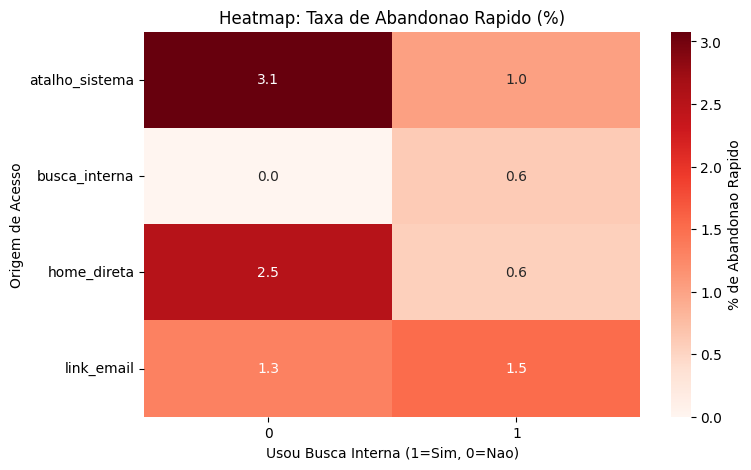

🔥 INSIGHT: Podemos observar cruzamentos de friccao. Se a busca gera muito abandono, a UX de pesquisa da intranet precisa ser refeita.


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

abandono_crosstab = pd.crosstab(
    index=df['origem_acesso'], 
    columns=df['usou_busca'], 
    values=df['abandono_rapido'], 
    aggfunc='mean'
).fillna(0) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(abandono_crosstab, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': '% de Abandonao Rapido'})
plt.title("Heatmap: Taxa de Abandonao Rapido (%)")
plt.xlabel("Usou Busca Interna (1=Sim, 0=Nao)")
plt.ylabel("Origem de Acesso")
plt.show()

print("🔥 INSIGHT: Podemos observar cruzamentos de friccao. Se a busca gera muito abandono, a UX de pesquisa da intranet precisa ser refeita.")

### 8.4.3 Teste Estatistico Avancado: O Efeito do Pico Matutino
Validando estatisticamente se o perodo das 08h-11h realmente reduz o tempo de leitura focado, usando um Teste T de Student.

In [34]:
from scipy import stats

grupo_matutino = df[(df['faixa_horaria'] == '08-11') & (df['clicou_comunicado'] == 1)]['tempo_leitura_segundos']
grupo_outros   = df[(df['faixa_horaria'] != '08-11') & (df['clicou_comunicado'] == 1)]['tempo_leitura_segundos']

t_stat, p_value = stats.ttest_ind(grupo_matutino, grupo_outros, equal_var=False)

print(f"Media Matutinao (08-11h): {grupo_matutino.mean():.1f}s")
print(f"Media Demais Horarios:   {grupo_outros.mean():.1f}s")
print(f"\nTeste T-Student: t={t_stat:.2f}, p-value={p_value:.4e}")

if p_value < 0.05:
    print(" RESULTADO: Existe uma diferenca estatisticamente significativa! O pico matutinao afeta o tempo de leitura de forma real e comprovada.")
else:
    print(" RESULTADO: A diferenca nao e estatisticamente significativa.")

Media Matutinao (08-11h): 70.9s
Media Demais Horarios:   75.3s

Teste T-Student: t=-1.80, p-value=7.2496e-02
 RESULTADO: A diferenca nao e estatisticamente significativa.


### 8.4.4 Distribuicao de Tempo por Dispositivo
Avalia como o tempo total de sessao varia entre Desktop e plataformas Mobile.

In [35]:
import plotly.express as px
import pandas as pd

fig = px.violin(df, y="tempo_total_segundos", x="tipo_dispositivo", color="tipo_dispositivo",
                box=True, points="all", hover_data=df.columns,
                title="Distribuicao do Tempo Total de Sessao por Dispositivo")
fig.show()
print('Grafico 8.4.4 (Violin Plot) gerado com sucesso.')

Grafico 8.4.4 (Violin Plot) gerado com sucesso.


### 8.4.5 Clusterizacao de Comportamento: Esforco vs Sucesso
Identifica clusters de comportamento cruzando o volume de interacoes (pageviews) com o tempo total, destacando sessoes de sucesso.

In [36]:
from sklearn.cluster import KMeans
import plotly.express as px

# Aplicamos um K-Means simples para justificar o titulo
X_cluster = df[['pageviews', 'tempo_total_segundos']].copy()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_comportamento'] = kmeans.fit_predict(X_cluster)
df['cluster_label'] = df['cluster_comportamento'].map({0: 'Baixo Engajamento', 1: 'Engajamento Medio', 2: 'Alto Engajamento'})

fig = px.scatter(df, x="pageviews", y="tempo_total_segundos", 
                 color="cluster_label", 
                 symbol="sucesso_encontrou_o_que_queria",
                 hover_data=['perfil_usuario', 'objetivo_sessao'],
                 title="Clusterizacao de Comportamento: Esforco (Tempo) vs. Volume (Pageviews)",
                 labels={'cluster_label': 'Cluster', 'sucesso_encontrou_o_que_queria': 'Sucesso'})
fig.show()
print('Grafico 8.4.5 (K-Means Clustering) gerado com sucesso.')

Grafico 8.4.5 (K-Means Clustering) gerado com sucesso.


### 8.4.6 Matriz de Correlacao Geral
Analisa a correlacao linear entre as variaveis numericas da base, validando se as logicas de tempo e abandonao fazem sentido estatistico.

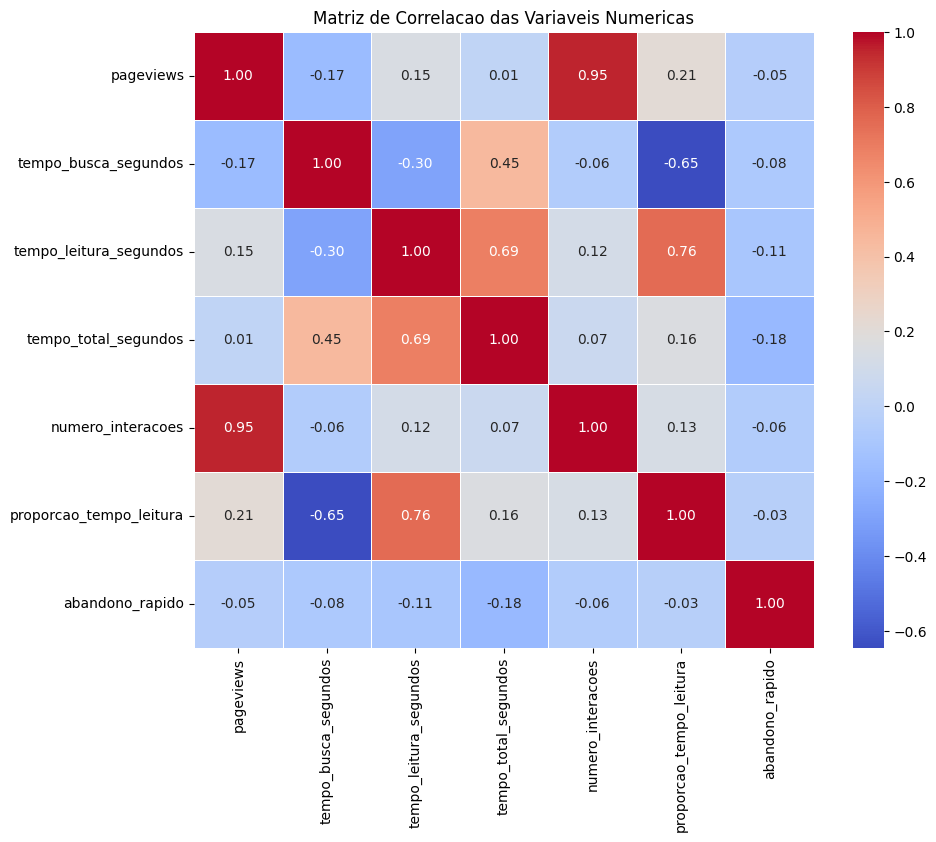

Grafico 8.4.6 (Heatmap de Correlacao) gerado com sucesso.


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['pageviews', 'tempo_busca_segundos', 'tempo_leitura_segundos', 'tempo_total_segundos', 'numero_interacoes', 'proporcao_tempo_leitura', 'abandono_rapido']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlacao das Variaveis Numericas")
plt.show()
print('Grafico 8.4.6 (Heatmap de Correlacao) gerado com sucesso.')

### 8.4.7 Impacto da Busca nao Sucesso por Perfil
Compara a taxa de sucesso das sessoes dependendo se o usuario utilizou ou nao a busca interna, segmentado por perfil.

In [38]:
# Calcula a taxa de sucesso
success_rate = df.groupby(['perfil_usuario', 'usou_busca'])['sucesso_encontrou_o_que_queria'].mean().reset_index()
success_rate['usou_busca'] = success_rate['usou_busca'].map({0: 'Nao Usou Busca', 1: 'Usou Busca'})
success_rate['Taxa de Sucesso (%)'] = success_rate['sucesso_encontrou_o_que_queria'] * 100

fig3 = px.bar(success_rate, x="perfil_usuario", y="Taxa de Sucesso (%)", color="usou_busca", barmode='group',
             title="Impacto do Uso da Busca Interna na Taxa de Sucesso por Perfil",
             text_auto='.1f')
fig3.show()
print('Grafico 8.4.7 (Bar Chart Agrupado) gerado com sucesso.')

Grafico 8.4.7 (Bar Chart Agrupado) gerado com sucesso.


### 8.5 Analise Preditiva: Modelando o Abandonao de Sessao (Machine Learning)
Treinamento de um classificador Random Forest para descobrir quais variaveis tem maior peso na predicao do abandonao rapido.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import pandas as pd

# Preparacao dos dados
df_ml = df.copy()
cat_cols = ['perfil_usuario', 'tipo_dispositivo', 'origem_acesso', 'objetivo_sessao', 'faixa_horaria']
le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Features e Target
features = ['perfil_usuario', 'tipo_dispositivo', 'origem_acesso', 'objetivo_sessao', 'pageviews', 'faixa_horaria']
X = df_ml[features]
y = df_ml['abandono_rapido']

# Treinamento
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X, y)

# Importancia das Variaveis
importances = pd.DataFrame({'Variavel': features, 'Importancia': rf.feature_importances_})
importances = importances.sort_values(by='Importancia', ascending=True)

fig_ml = px.bar(importances, x='Importancia', y='Variavel', orientation='h',
             title='Importancia das Variaveis na Predicao de Abandonao (Random Forest)')
fig_ml.show()
print('Grafico 8.5 (Feature Importance ML) gerado com sucesso.')

Grafico 8.5 (Feature Importance ML) gerado com sucesso.


### 8.6 Fluxo de Navegacao: O Caminho do Usuario (Sankey Diagram)
Mapeamento visual do fluxo desde a origem do acesso ate o resultado da sessao.

In [40]:
import plotly.graph_objects as go

# Agrupar os fluxos principais
flow_df = df.groupby(['origem_acesso', 'objetivo_sessao', 'sucesso_encontrou_o_que_queria']).size().reset_index(name='count')
flow_df['sucesso_label'] = flow_df['sucesso_encontrou_o_que_queria'].map({1: 'Sucesso', 0: 'Falha/Abandono'})

# Criar nos
all_nodes = list(flow_df['origem_acesso'].unique()) + list(flow_df['objetivo_sessao'].unique()) + list(flow_df['sucesso_label'].unique())
node_indices = {node: i for i, node in enumerate(all_nodes)}

# Criar links
source = []
target = []
value = []

for _, row in flow_df.iterrows():
    # Origem -> Objetivo
    source.append(node_indices[row['origem_acesso']])
    target.append(node_indices[row['objetivo_sessao']])
    value.append(row['count'])
    
    # Objetivo -> Sucesso
    source.append(node_indices[row['objetivo_sessao']])
    target.append(node_indices[row['sucesso_label']])
    value.append(row['count'])

fig_sankey = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = all_nodes,
      color = "blue"
    ),
    link = dict(
      source = source,
      target = target,
      value = value
  ))])

fig_sankey.update_layout(title_text="Diagrama de Sankey: Jornada do Usuario na Intranet", font_size=10)
fig_sankey.show()
print('Grafico 8.6 (Sankey Diagram) gerado com sucesso.')

Grafico 8.6 (Sankey Diagram) gerado com sucesso.


### 8.7 Teste A/B Simulado: Experiencia Desktop vs Mobile
Teste estatistico (Z-Test de Proporcoes) para validar se a taxa de sucesso difere significativamente entre as plataformas.

In [41]:
from statsmodels.stats.proportion import proportions_ztest
import pandas as pd

# Vamos agrupar mobile_web e mobile_app como 'mobile'
df_ab = df.copy()
df_ab['plataforma'] = df_ab['tipo_dispositivo'].apply(lambda x: 'desktop' if x == 'desktop' else 'mobile')

# Calculo de sucessos e totais
sucessos = df_ab.groupby('plataforma')['sucesso_encontrou_o_que_queria'].sum()
totais = df_ab.groupby('plataforma')['sucesso_encontrou_o_que_queria'].count()

count = [sucessos['desktop'], sucessos['mobile']]
nobs = [totais['desktop'], totais['mobile']]

# Teste Z para proporcoes
z_stat, p_value = proportions_ztest(count, nobs)

taxa_desk = sucessos['desktop'] / totais['desktop']
taxa_mob = sucessos['mobile'] / totais['mobile']

print("Teste A/B: Taxa de Sucesso (Desktop vs Mobile)")
print("-" * 45)
print(f"Taxa Desktop: {taxa_desk:.1%} (n={totais['desktop']})")
print(f"Taxa Mobile:  {taxa_mob:.1%} (n={totais['mobile']})")
print(f"Z-Statistic:  {z_stat:.3f}")
print(f"P-Value:      {p_value:.4f}")
print("-" * 45)

if p_value < 0.05:
    print("Veredito: Existe diferenca estatistica significativa entre Desktop e Mobile.")
else:
    print("Veredito: Nao ha diferenca estatistica significativa.")


Teste A/B: Taxa de Sucesso (Desktop vs Mobile)
---------------------------------------------
Taxa Desktop: 72.3% (n=4873)
Taxa Mobile:  73.2% (n=127)
Z-Statistic:  -0.242
P-Value:      0.8089
---------------------------------------------
Veredito: Nao ha diferenca estatistica significativa.
